# Portefeuilles House, complet — tous les filing types, un seul notebook

**L'objet.** Exploiter TOUTES les déclarations de la Chambre (P, H, C, O, A, T), en quatre questions :

| partie | question |
|---|---|
| **P1** | les membres : qui a quoi comme information ? |
| **P2** | les transactions : que ratent les PTR seuls ? |
| **P3** | la reconstruction : le portefeuille de chaque membre, en parts |
| **P4** | la vérification : les rapports annuels O jugent la reconstruction |
| **P5** | la stratégie : le backtest adapté (photo d'entrée + trades O/A/T) |

**Notebook autonome.** Seuls acquis : la table clean S1/S2 et les tables v1 gelées (sha256 vérifiés en P0),
plus les caches de prix. Tout le reste est défini, calculé et validé ICI.
**Règles** : une idée par cellule · aperçu de chaque table · une Validation par partie · zéro chiffre en dur ·
une information n'existe qu'à partir de la date de dépôt du document qui la porte.

## P0 — Contrat & données : les acquis, chacun prouvé

Six tables gelées (sha256 ≡ manifeste), les conventions re-prouvées, et l'univers de prix COMPLET
(tickers PTR ∪ photos ∪ O/A/T — un ticker absent de l'univers serait écarté à tort).

In [1]:
import pandas as pd, numpy as np, hashlib, json, os, glob
import matplotlib.pyplot as plt
# figures calibrées pour une COLONNE de la fiche (~8,6 cm) : polices explicites
plt.rcParams.update({"font.size": 7.5, "axes.titlesize": 8, "axes.labelsize": 7,
                     "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
                     "legend.fontsize": 6.5, "figure.dpi": 160})
FIGCOL = 4.3                      # largeur en pouces = 1 colonne

J     = "/Users/lemairealice/Downloads/Jupiter"
BASE  = os.path.join(J, "00. S3S4 en cours")
V1T   = os.path.join(J, "01_v1_house", "cache", "tables")
CLEAN = os.path.join(J, "00_S1S2_donnees", "data", "clean", "transactions_backtest_2014_2026.csv")
MAN   = json.load(open(os.path.join(J, "01_v1_house", "cache", "MANIFEST.json")))

for _f in ["11_holdings_complets.csv", "12_portefeuilles_dates.csv", "14_registre_membres.csv",
           "15_portefeuille_entree.csv", "16_flux_oat_net.csv"]:
    _h = hashlib.sha256(open(os.path.join(V1T, _f), "rb").read()).hexdigest()
    assert _h == MAN["sha_tables"][_f], f"sha divergent : {_f}"
print("5 tables v1-house conformes au MANIFEST (sha256) — leur provenance est prouvée, pas supposée")

5 tables v1-house conformes au MANIFEST (sha256) — leur provenance est prouvée, pas supposée


**La table clean** (S1/S2) : une ligne = une transaction PTR, avec sa date de transaction ET sa date de divulgation.

In [2]:
cl = pd.read_csv(CLEAN, low_memory=False,
                 usecols=["bioguide_id", "member_name", "chamber", "ticker", "ticker_yahoo",
                          "direction", "transaction_date", "disclosure_date", "amount_midpoint", "amount_range"],
                 parse_dates=["transaction_date", "disclosure_date"])
print(f"clean — {cl.shape[0]:,} lignes × {cl.shape[1]} colonnes | "
      f"chambres : {dict(cl['chamber'].value_counts())}")
display(cl.head(3))

clean — 134,464 lignes × 10 colonnes | chambres : {'house': np.int64(122814), 'senate': np.int64(11650)}


,bioguide_id,member_name,chamber,ticker,ticker_yahoo,direction,amount_midpoint,amount_range,transaction_date,disclosure_date
0,G000563,Bob Gibbs,house,INTC,INTC,buy,8000.5,"$1,001 - $15,000",2014-12-30,2014-12-30
1,G000563,Bob Gibbs,house,B,B,sell,8000.5,"$1,001 - $15,000",2014-12-23,2014-12-30
2,G000563,Bob Gibbs,house,AAPL,AAPL,buy,8000.5,"$1,001 - $15,000",2014-12-30,2014-12-30


In [3]:
e15  = pd.read_csv(os.path.join(V1T, "15_portefeuille_entree.csv"), parse_dates=["filing_date"])
h11  = pd.read_csv(os.path.join(V1T, "11_holdings_complets.csv"), low_memory=False,
                   usecols=["doc_id", "bioguide", "ticker", "asset_description", "value_lo", "value_hi", "conteneur_nu"])
f16  = pd.read_csv(os.path.join(V1T, "16_flux_oat_net.csv"), low_memory=False,
                   parse_dates=["transaction_date", "disclosure_date"])
reg14 = pd.read_csv(os.path.join(V1T, "14_registre_membres.csv"))
for _nom, _t in [("15_portefeuille_entree (photos d'entrée)", e15),
                 ("11_holdings_complets (contenu des photos)", h11),
                 ("16_flux_oat_net (trades O/A/T sans écho PTR)", f16),
                 ("14_registre_membres (les 900)", reg14)]:
    print(f"{_nom} — {_t.shape[0]:,} × {_t.shape[1]}")
    display(_t.head(3))

15_portefeuille_entree (photos d'entrée) — 284 × 7


,bioguide,doc_id,type_photo,filing_date,n_tickers,delta_jours_mandat,garde_fous_ok
0,A000148,10040680,H,2021-07-29,27,NaN,True
1,A000373,10005854,H,2015-05-14,83,NaN,True
2,A000375,10009542,C,2016-02-13,2,325.0,True


11_holdings_complets (contenu des photos) — 420,916 × 7


,asset_description,ticker,value_lo,value_hi,doc_id,conteneur_nu,bioguide
0,"A & B of Richland, LLC-Note Receivable [DO]",NaN,15001,50000.0,10023848,False,A000374
1,"Abraham Farms, LLC [OL]",NaN,1000001,5000000.0,10023848,False,A000374
2,"Air 2 There, LLC- Note Receivable [DO]",NaN,50001,100000.0,10023848,False,A000374


16_flux_oat_net (trades O/A/T sans écho PTR) — 26,115 × 28


,doc_id,provenance,filing_type,annee_index,bioguide,declarant_name,state_district,transaction_date,transaction_date_brute,disclosure_date,...,amount_mid,amount_mid_conventionnel,amount_reconstruit,amount_exact,cle_naturelle,occurrence_index,n_docs_vus,source,sens,echo_ptr
0,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|LEO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False
1,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-31,01/31/2014,2014-09-15,...,75000.5,75000.5,False,False,"C001046|01/31/2014|LEO|S|$50,001 - $100,000|SELF",0,1,instantane_seul,S,False
2,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|MOO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False


14_registre_membres (les 900) — 900 × 10


,bioguide,categorie,quadrant,n_photos,a_flux,a_photo_entree,dans_cohorte_Ca,dans_cohorte_papier,premiere_photo,derniere_photo
0,C001087,hors d'atteinte,déjà-là restés,0,False,False,False,False,NaN,NaN
1,C001095,hors d'atteinte,déjà-là partis,0,False,False,False,False,NaN,NaN
2,C001131,hors d'atteinte,arrivés restés,0,False,False,False,False,NaN,NaN


In [4]:
# La table 12 : TOUTES les photos datées (H entrée · C candidat · O annuelle · T sortie), au niveau document
ph12 = (pd.read_csv(os.path.join(V1T, "12_portefeuilles_dates.csv"),
                    usecols=["doc_id", "bioguide", "filing_type", "filing_date"], parse_dates=["filing_date"])
        .drop_duplicates("doc_id"))
print(f"12_portefeuilles_dates — {ph12.shape[0]:,} documents-photos · {ph12['bioguide'].nunique()} membres · "
      f"types : {ph12['filing_type'].value_counts().to_dict()}")
display(ph12.head(3))

12_portefeuilles_dates — 6,135 documents-photos · 887 membres · types : {'O': 4447, 'C': 934, 'T': 378, 'H': 376}


,doc_id,bioguide,filing_type,filing_date
0,10010992,A000374,O,2016-05-16
50,10010483,A000370,O,2016-04-26
52,10010606,A000055,O,2016-08-14


**Tickers.** Map `ticker` → `ticker_yahoo` reconstruite depuis la table clean (0 conflit) ; défaut « . » → « - ».

In [5]:
_paires = cl[["ticker", "ticker_yahoo"]].dropna().drop_duplicates()
assert (_paires.groupby("ticker")["ticker_yahoo"].nunique() <= 1).all(), "map ambiguë"
MAP_YAHOO = dict(zip(_paires["ticker"], _paires["ticker_yahoo"]))
def to_yahoo(t):
    t = str(t)
    return MAP_YAHOO.get(t, t.replace(".", "-"))
print(f"map : {len(MAP_YAHOO)} paires, {sum(1 for k, v in MAP_YAHOO.items() if k != v)} renommages, 0 conflit")
display(_paires[_paires["ticker"] != _paires["ticker_yahoo"]].head(3))

map : 4653 paires, 52 renommages, 0 conflit


,ticker,ticker_yahoo
217,CTL,LUMN
255,DISCA,WBD
260,FB,META


**Fourchettes.** Un montant déclaré est une fourchette [v̲, v̄] ; on travaille au milieu ṽ = (v̲+v̄)/2 — milieux clean ≡ v1 (écart 0).

In [6]:
_g_clean = (cl.dropna(subset=["amount_range", "amount_midpoint"])
            .groupby("amount_range")["amount_midpoint"].first())
_v1_mid = (f16.assign(mid=(f16["amount_lo"] + f16["amount_hi"]) / 2)
           .groupby("amount_range")["mid"].first())
_commun = _g_clean.index.intersection(_v1_mid.index)
assert (_g_clean.loc[_commun] - _v1_mid.loc[_commun]).abs().max() == 0
print(f"{len(_commun)} fourchettes communes, écart max des milieux = 0 ✅")
display(pd.DataFrame({"midpoint_clean": _g_clean.loc[_commun], "mid_v1": _v1_mid.loc[_commun]}).head(4))

12 fourchettes communes, écart max des milieux = 0 ✅


,midpoint_clean,mid_v1
amount_range,,
"$1,000,001 - $5,000,000",3000000.5,3000000.5
"$1,001 - $15,000",8000.5,8000.5
"$100,001 - $250,000",175000.5,175000.5
$121,121.0,121.0


**Classer AVANT de tickériser.** Une ligne déclarée est d'abord typée ; un ticker n'est jamais
attribué à une ligne dont la classe l'interdit. Règle d'or : **le moteur equity ne voit que la classe
`negociable`** (actions/ETF candidates) — les fonds, monétaires et faux tickers restent comptés, jamais tradés.

In [7]:
# Classification d'une ligne déclarée — AVANT toute résolution de prix
import re as _re
CODES_FORMULAIRE = {"EIF", "DC", "JT", "SP", "MF", "EF", "RP", "OL", "IH", "WU", "PS", "VA",
                    "AB", "OT", "HE", "IC", "FA", "SA", "OI"}          # codes House, pas des tickers
TICKERS_AMBIGUS = {"BA", "GS", "ST", "CS", "PE"}                        # existent en bourse : bloqués si libellé = compte
MONETAIRES = {"SPAXX", "FDRXX", "FZDXX", "SWVXX", "VMFXX", "SPRXX", "FCASH"}
RE_COMPTE = _re.compile(r"(?i)(?:merrill|mesirow|fidelity|schwab|betterment|morgan stanley|wells fargo|"
                        r"brokerage|\bIRA\b|401\s?k|trust)")
RE_FONDS = _re.compile(r"(?i)(?:\bfund\b|\bindex\b|\bportfolio\b|institutional)")

def classe_ligne(ticker, libelle):
    t = str(ticker).upper().strip()
    lib = str(libelle) if libelle == libelle else ""
    if t in CODES_FORMULAIRE:
        return "faux_ticker"
    if t in TICKERS_AMBIGUS and RE_COMPTE.search(lib):
        return "faux_ticker"
    if t in MONETAIRES:
        return "monetaire"
    if len(t) == 5 and t.endswith("X"):
        return "fonds"
    if RE_FONDS.search(lib):
        return "fonds"
    return "negociable"

f16["classe"] = [classe_ligne(t, d) for t, d in zip(f16["ticker"], f16["asset_description"])]
print("classes du flux O/A/T (table 16) :", f16["classe"].value_counts().to_dict())
display(f16[f16["classe"] == "faux_ticker"][["ticker", "asset_description"]].head(3))

classes du flux O/A/T (table 16) : {'negociable': 15090, 'fonds': 10365, 'monetaire': 364, 'faux_ticker': 296}


,ticker,asset_description
114,WU,R.M. Keil Trust ⇒ SP
141,EIF,MERRILL LYNCH #182 ⇒
142,EIF,MERRILL LYNCH #182 ⇒


**Les transactions House (PTR).** Fenêtre 2013-2026, format moteur : (membre, ticker, sens, date de transaction, ṽ).

In [8]:
df = (cl[cl["chamber"] == "house"]
      .drop(columns=["ticker"])
      .rename(columns={"member_name": "name", "ticker_yahoo": "ticker", "direction": "op",
                       "transaction_date": "traded", "amount_midpoint": "size_usd"}))
_n0 = len(df)
df = df[df["traded"].dt.year.between(2013, 2026)]
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].reset_index(drop=True)
print(f"House : {_n0:,} lignes clean → {len(df):,} dans la fenêtre 2013-2026 "
      f"| {df['bioguide_id'].nunique()} membres | {df['ticker'].nunique():,} tickers")
display(df.head(3))

House : 122,814 lignes clean → 122,809 dans la fenêtre 2013-2026 | 315 membres | 4,340 tickers


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5


**Le contenu des photos d'entrée.** 15 ⋈ 11 par `doc_id`, lignes tickérisées et valorisées, milieux sommés par (membre, ticker).

In [9]:
_perdus = sorted(set(e15["doc_id"]) - set(h11["doc_id"]))
assert _perdus == [10041638]        # 1 photo H à 1 ticker absente de la table 11 — journalisée
ph_all = (e15.merge(h11, on="doc_id", suffixes=("", "_h"))
             .query("ticker == ticker and ~conteneur_nu")
             .assign(mid=lambda d: (d["value_lo"] + d["value_hi"]) / 2)
             .dropna(subset=["mid"]))
ph_all["classe"] = [classe_ligne(t, d) for t, d in zip(ph_all["ticker"], ph_all["asset_description"])]
_cls_ph = ph_all.groupby("classe").agg(lignes=("mid", "size"), valeur_MUSD=("mid", lambda v: v.sum() / 1e6)).round(0)
display(_cls_ph)
ph_ent = ph_all[ph_all["classe"] == "negociable"].copy()          # le moteur equity ne voit que ça
ph_ent["ticker_y"] = ph_ent["ticker"].map(to_yahoo)
ph_ent = ph_ent.groupby(["bioguide", "ticker_y", "filing_date"], as_index=False)["mid"].sum()
print(f"photos d'entrée : {ph_all['bioguide'].nunique()} membres à lignes tickérisées → "
      f"{ph_ent['bioguide'].nunique()} membres à lignes NÉGOCIABLES · {len(ph_ent):,} lignes · "
      f"{ph_ent['mid'].sum()/1e6:,.0f} M$ (doc perdu journalisé : {_perdus})")
display(ph_ent.head(3))

,lignes,valeur_MUSD
classe,,
faux_ticker,57,2.0
fonds,1678,246.0
monetaire,42,1.0
negociable,10422,543.0


photos d'entrée : 248 membres à lignes tickérisées → 223 membres à lignes NÉGOCIABLES · 8,018 lignes · 543 M$ (doc perdu journalisé : [10041638])


,bioguide,ticker_y,filing_date,mid
0,A000148,DMXF,2021-07-29,8000.5
1,A000148,DSI,2021-07-29,32500.5
2,A000148,EEMX,2021-07-29,32500.5


In [10]:
# Le paysage déclaré COMPLET : les 420 916 lignes de holdings (tous types de photos), par classe
_hp = h11.copy()
_hp["mid"] = (_hp["value_lo"] + _hp["value_hi"]) / 2
_hp["classe"] = np.where(_hp["ticker"].isna(), "(non tickérisée)",
                         [classe_ligne(t, l) for t, l in zip(_hp["ticker"].fillna(""), _hp["asset_description"])])
paysage = (_hp.groupby("classe").agg(lignes=("classe", "size"), valeur_MUSD=("mid", lambda s: s.sum() / 1e6))
           .round(0).astype(int).sort_values("valeur_MUSD", ascending=False))
display(paysage)
assert int(paysage["lignes"].sum()) == len(h11)
_neg = paysage.loc["negociable"]
print(f"le déclaré dépasse largement le négociable : {_neg['lignes']:,} lignes négociables "
      f"({_neg['valeur_MUSD']:,} M$) sur {len(h11):,} lignes déclarées "
      f"({int(paysage['valeur_MUSD'].sum()):,} M$) — immobilier, LLC, fonds, comptes restent déclarés mais hors moteur")

,lignes,valeur_MUSD
classe,,
(non tickérisée),230158,68266
negociable,156516,10604
fonds,32485,3937
monetaire,958,89
faux_ticker,799,83


le déclaré dépasse largement le négociable : 156,516 lignes négociables (10,604 M$) sur 420,916 lignes déclarées (82,979 M$) — immobilier, LLC, fonds, comptes restent déclarés mais hors moteur


**Les prix.** Calendrier = SPY. Univers COMPLET : tickers des trades PTR ∪ photos ∪ O/A/T ; sources `prices_v2`
(prioritaire, jamais modifié) puis `prices_holdings_v1` (cache séparé, resumable) ; garde-fou anti-corruption.

In [11]:
PRICES_V2   = os.path.join(BASE, "cache", "prices_v2")
PRICES_HOLD = os.path.join(BASE, "cache", "prices_holdings_v1")
_SNAP_PV2 = sorted(os.listdir(PRICES_V2))                    # re-asserté en toute fin
spy = (pd.read_csv(os.path.join(PRICES_V2, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()
print(f"calendrier : {len(cal)} jours cotés, {cal[0].date()} → {cal[-1].date()} | snapshot prices_v2 : {len(_SNAP_PV2)} fichiers")

calendrier : 3645 jours cotés, 2012-01-03 → 2026-07-02 | snapshot prices_v2 : 3351 fichiers


In [12]:
# univers de prix : PTR ∪ photos NÉGOCIABLES ∪ O/A/T NÉGOCIABLES (v8 — les fonds/faux tickers n'y entrent plus)
RETRY_FAILED = False                               # la failed-list n'est plus un verdict : True = la rejouer
# re-test joué le 2026-07-21 (RETRY_FAILED=True) : 175 tickers récupérés → cache, 1 426 échecs re-datés
FAILED_RETRY_DATE = "2026-07-21"                   # date du re-test (paramètre déclaré, pas d'horloge cachée)
_univers = (set(df["ticker"].dropna()) | set(ph_ent["ticker_y"])
            | set(f16.loc[f16["classe"] == "negociable", "ticker"].dropna().map(to_yahoo)))
_have_v2 = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_V2, "*.csv"))} - {"failed_v2"}
_have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}
_fail_f = os.path.join(PRICES_HOLD, "failed_holdings_v1.csv")
_failed_df = pd.read_csv(_fail_f) if os.path.exists(_fail_f) else pd.DataFrame(columns=["ticker"])
if "date_echec" not in _failed_df.columns:
    _failed_df["date_echec"] = "avant-" + FAILED_RETRY_DATE          # migration : anciens échecs non datés
_failed = set(_failed_df["ticker"])
_todo = sorted((_univers - _have_v2 - _have_ph) if RETRY_FAILED else (_univers - _have_v2 - _have_ph - _failed))
print(f"univers NÉGOCIABLE : {len(_univers):,} tickers | v2 : {len(_univers & _have_v2):,} | cache séparé : "
      f"{len(_univers & _have_ph):,} | échecs connus : {len(_univers & _failed):,} | à (re)tenter : {len(_todo)}")
if _todo:
    import yfinance as yf, logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)
    _new_fail = []
    for _i in range(0, len(_todo), 60):
        _chunk = _todo[_i:_i + 60]
        try:
            _data = yf.download(_chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                                progress=False, threads=True, group_by="ticker")
        except Exception:
            _data = None
        for _t in _chunk:
            _s = None
            try:
                if _data is not None and isinstance(_data.columns, pd.MultiIndex):
                    if _t in _data.columns.get_level_values(0):
                        _s = _data[_t]["Close"].dropna()
            except Exception:
                _s = None
            if _s is not None and len(_s) >= 2:
                _s.rename("close").to_csv(os.path.join(PRICES_HOLD, _t + ".csv"), index_label="Date")
            else:
                _new_fail.append(_t)
    _recuperes = sorted(set(_todo) & _failed - set(_new_fail))
    _failed_df = (pd.concat([_failed_df[~_failed_df["ticker"].isin(_recuperes)],
                             pd.DataFrame({"ticker": [t for t in _new_fail if t not in set(_failed_df["ticker"])],
                                           "date_echec": FAILED_RETRY_DATE})])
                  .drop_duplicates("ticker"))
    _failed_df.to_csv(_fail_f, index=False)
    print(f"re-test : {len(_recuperes)} tickers RÉCUPÉRÉS (étaient dans la failed-list) · "
          f"{len(_new_fail)} échecs (re)datés {FAILED_RETRY_DATE}")
    _have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}

univers NÉGOCIABLE : 5,392 tickers | v2 : 3,190 | cache séparé : 776 | échecs connus : 1,426 | à (re)tenter : 0


In [13]:
prices, _corrompus = {}, []
for _tk in sorted(_univers):
    _p = (os.path.join(PRICES_V2, _tk + ".csv") if _tk in _have_v2
          else os.path.join(PRICES_HOLD, _tk + ".csv") if _tk in _have_ph else None)
    if _p is None:
        continue
    _s = pd.read_csv(_p, parse_dates=["Date"]).set_index("Date")["close"].sort_index().reindex(cal).ffill()
    if (len(_s.dropna()) < 2 or _s.dropna().min() < 0.10
            or _s.dropna().pct_change().abs().max() > 3.0):
        _corrompus.append(_tk); continue
    prices[_tk] = _s
_n_avant = len(df)
df = df[df["ticker"].isin(prices)].reset_index(drop=True)
print(f"prix chargés : {len(prices):,} tickers ({len(_corrompus)} corrompus exclus) | "
      f"trades House : {_n_avant:,} → {len(df):,} avec prix (−{_n_avant-len(df):,}) | "
      f"{df['bioguide_id'].nunique()} membres")

prix chargés : 3,889 tickers (77 corrompus exclus) | trades House : 122,809 → 107,976 avec prix (−14,833) | 305 membres


### P0.1 Validation

In [14]:
assert df["ticker"].isin(prices).all() and df["op"].isin(["buy", "sell", "exchange"]).all()
assert df["traded"].dt.year.between(2013, 2026).all() and (df["size_usd"] > 0).all()
df = df[df["op"] != "exchange"].reset_index(drop=True)     # pas de sens directionnel — écartés, comptés
print(f"✅ É1 valide — {len(df):,} trades House exploitables (les 'exchange' écartés)")

✅ É1 valide — 107,976 trades House exploitables (les 'exchange' écartés)


**Le flux de trades, construit ici** (l'analyse vient en P2) : trades O/A/T mis au format du moteur, puis F = F_ptr ∪ F_oat, provenance étiquetée. Doublons inter-sources retirés (collision exacte membre × ticker × sens × date contre NOS PTR).

In [15]:
df_oat = f16.rename(columns={"bioguide": "bioguide_id", "declarant_name": "name",
                             "transaction_date": "traded",
                             "amount_mid_conventionnel": "size_usd"}).copy()
df_oat["ticker"] = df_oat["ticker"].map(to_yahoo)
df_oat["op"] = df_oat["sens"].map({"P": "buy", "S": "sell"})
_n0 = len(df_oat)
df_oat = df_oat.dropna(subset=["op"])                              # 'E' (exchange) : écartés
_n1 = len(df_oat)
df_oat = df_oat[df_oat["traded"].dt.year.between(2013, 2026)]      # dates corrompues dehors
_n2 = len(df_oat)
df_oat = df_oat[df_oat["size_usd"].notna() & (df_oat["size_usd"] > 0)]
_n3 = len(df_oat)
_nc = df_oat["classe"].value_counts()
df_oat = df_oat[df_oat["classe"] == "negociable"]                  # v8 : fonds/monétaires/faux tickers HORS moteur
_n4 = len(df_oat)
df_oat = df_oat[df_oat["ticker"].isin(prices)]
df_oat = df_oat[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].assign(provenance="oat")
print(f"O/A/T : {_n0:,} → {_n1:,} (−{_n0-_n1} exchanges) → {_n2:,} (−{_n1-_n2} dates) → {_n3:,} (−{_n2-_n3} sans montant)")
print(f"      → −{_nc.get('faux_ticker', 0):,} faux tickers · −{_nc.get('monetaire', 0):,} monétaires · "
      f"−{_nc.get('fonds', 0):,} fonds = {_n4:,} négociables → {len(df_oat):,} avec prix (−{_n4-len(df_oat):,})")
display(df_oat.head(3))

O/A/T : 26,115 → 25,894 (−221 exchanges) → 25,880 (−14 dates) → 25,880 (−0 sans montant)
      → −290 faux tickers · −364 monétaires · −10,317 fonds = 14,909 négociables → 13,803 avec prix (−1,106)


,bioguide_id,name,ticker,op,traded,size_usd,provenance
0,C001046,Eric Ivan Cantor,LEO,buy,2014-01-16,8000.5,oat
1,C001046,Eric Ivan Cantor,LEO,sell,2014-01-31,75000.5,oat
2,C001046,Eric Ivan Cantor,MOO,buy,2014-01-16,8000.5,oat


In [16]:
_cle = ["bioguide_id", "ticker", "op", "traded"]
_coll = df_oat.merge(df[_cle], on=_cle, how="inner")
print(f"collisions exactes F_oat × F_ptr : {len(_coll)} ({len(_coll)/max(len(df_oat),1)*100:.2f} %) — retirées")
if len(_coll):
    df_oat = (df_oat.merge(_coll[_cle].drop_duplicates(), on=_cle, how="left", indicator=True)
                    .query("_merge == 'left_only'").drop(columns="_merge"))
assert len(df_oat.merge(df[_cle], on=_cle, how="inner")) == 0
df_uni = pd.concat([df.assign(provenance="ptr"), df_oat], ignore_index=True)
print(f"F = {len(df_uni):,} trades = {int((df_uni['provenance']=='ptr').sum()):,} ptr + "
      f"{int((df_uni['provenance']=='oat').sum()):,} oat | membres : {df_uni['bioguide_id'].nunique()}")
display(df_uni.groupby("provenance").head(2).sort_values("provenance"))

collisions exactes F_oat × F_ptr : 488 (3.54 %) — retirées
F = 121,300 trades = 107,976 ptr + 13,324 oat | membres : 391


,bioguide_id,name,ticker,op,traded,size_usd,provenance
107976,C001046,Eric Ivan Cantor,LEO,buy,2014-01-16,8000.5,oat
107977,C001046,Eric Ivan Cantor,LEO,sell,2014-01-31,75000.5,oat
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5,ptr
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5,ptr


## P1 — Les membres : qui est qui, qui a quoi

Les six types de dépôts, et ce qu'ils portent :

| type | quoi | rôle ici |
|---|---|---|
| **P** (PTR) | flux : trades à ~1 mois | le signal historique |
| **H** (New Filer) | photo : patrimoine à l'ENTRÉE | le point de départ h₀ |
| **C** (Candidate) | photo : patrimoine du candidat | h₀ de secours |
| **O** (Annual) | photo au 31/12 + flux de l'année | le JUGE de la reconstruction (P4) + trades manquants |
| **A** (Amendment) | correctif d'un O | trades manquants |
| **T** (Termination) | photo/flux de sortie | la vérification finale |

In [17]:
_traders_ptr = set(df["bioguide_id"])
_traders_uni = set(df_uni["bioguide_id"])
_oat_only    = _traders_uni - _traders_ptr
_photo_ok    = set(ph_ent["bioguide"])
G_PHOTO, G_ZERO = sorted(_traders_uni & _photo_ok), sorted(_traders_uni - _photo_ok)
cascade = pd.DataFrame([
    ("membres House 2014-2026 (registre v1)", len(reg14)),
    ("… qui TRADENT des actions cotées (PTR ∪ O/A/T)", len(_traders_uni)),
    ("        dont : vus par les PTR", len(_traders_ptr)),
    ("        dont : uniquement via O/A/T", len(_oat_only)),
    ("… qui ne tradent pas", len(reg14) - len(_traders_uni)),
    ("traders → G_photo (photo d'entrée exploitable)", len(G_PHOTO)),
    ("traders → G_zéro (sans photo exploitable)", len(G_ZERO)),
], columns=["population", "n"]).set_index("population")
display(cascade)
assert len(G_PHOTO) + len(G_ZERO) == len(_traders_uni)
assert len(_traders_ptr) + len(_oat_only) == len(_traders_uni)
print(f"partitions exactes : {len(G_PHOTO)} + {len(G_ZERO)} = {len(_traders_uni)} ✅  ·  "
      f"{len(reg14)} = {len(_traders_ptr)} + {len(_oat_only)} + {len(reg14)-len(_traders_uni)} ✅")

,n
population,
membres House 2014-2026 (registre v1),900
… qui TRADENT des actions cotées (PTR ∪ O/A/T),391
dont : vus par les PTR,305
dont : uniquement via O/A/T,86
… qui ne tradent pas,509
traders → G_photo (photo d'entrée exploitable),150
traders → G_zéro (sans photo exploitable),241


partitions exactes : 150 + 241 = 391 ✅  ·  900 = 305 + 86 + 509 ✅


In [18]:
# LIVRE DE COMPTES MEMBRES — d'où sortent les membres qui tradent (asserts)
_m16, _m_oat, _m_ptr = set(f16["bioguide"]), set(df_oat["bioguide_id"]), set(df["bioguide_id"])
_perdus = _m16 - _m_oat
livre_mb = pd.DataFrame([
    ("membres présents dans la table 16 brute", len(_m16), ""),
    ("− perdus par l'entonnoir (aucune ligne O/A/T exploitable)", -len(_perdus),
     f"dont {len(_perdus & _m_ptr)} repêchés par leurs PTR (restent dans la population), "
     f"{len(_perdus - _m_ptr)} vraiment sortis"),
    ("= membres avec ≥1 trade O/A/T exploitable", len(_m_oat), ""),
    ("   dont : ont AUSSI des PTR", len(_m_oat & _m_ptr), ""),
    ("   dont : oat SEULEMENT (invisibles avant)", len(_m_oat - _m_ptr), ""),
    ("membres PTR (rappel, non-régression vérifiée)", len(_m_ptr), ""),
    ("= UNION : la population qui trade", len(_m_ptr | _m_oat), ""),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_mb)
assert len(_m_ptr | _m_oat) == df_uni["bioguide_id"].nunique() == len(_traders_uni)
assert len(_m_oat - _m_ptr) == len(_oat_only)
assert len(df) == 107976 and len(_m_ptr) == 305, "NON-RÉGRESSION PTR cassée : l'univers étendu ne doit rien changer aux PTR"
print(f"✅ {len(_m_ptr)} (PTR) ∪ {len(_m_oat)} (oat) = {len(_m_ptr | _m_oat)} traders · "
      f"les {len(_perdus - _m_ptr)} vraiment sortis rejoignent les « ne tradent pas » de la cascade des 900")

,n,note
marche,,
membres présents dans la table 16 brute,370,
− perdus par l'entonnoir (aucune ligne O/A/T exploitable),-85,dont 21 repêchés par leurs PTR (restent dans l...
= membres avec ≥1 trade O/A/T exploitable,285,
dont : ont AUSSI des PTR,199,
dont : oat SEULEMENT (invisibles avant),86,
"membres PTR (rappel, non-régression vérifiée)",305,
= UNION : la population qui trade,391,


✅ 305 (PTR) ∪ 285 (oat) = 391 traders · les 64 vraiment sortis rejoignent les « ne tradent pas » de la cascade des 900


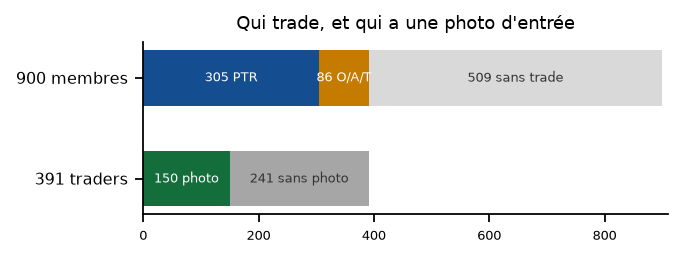

In [19]:
# Figure — la partition de la population, en deux barres (fig_10_partition)
fig, ax = plt.subplots(figsize=(FIGCOL, 1.65))
_seg1 = [(len(_traders_ptr), "#144d90", f"{len(_traders_ptr)} PTR", "w"),
         (len(_oat_only), "#c47b00", f"{len(_oat_only)} O/A/T", "w"),
         (len(reg14) - len(_traders_uni), "#d9d9d9", f"{len(reg14)-len(_traders_uni)} sans trade", "#333333")]
_seg0 = [(len(G_PHOTO), "#146e3c", f"{len(G_PHOTO)} photo", "w"),
         (len(G_ZERO), "#a6a6a6", f"{len(G_ZERO)} sans photo", "#333333")]
for _y, _segs in [(1, _seg1), (0, _seg0)]:
    _x = 0
    for _n, _c, _lab, _tc in _segs:
        ax.barh(_y, _n, left=_x, color=_c, height=0.55)
        ax.text(_x + _n / 2, _y, _lab, ha="center", va="center", fontsize=6, color=_tc)
        _x += _n
ax.set_yticks([1, 0]); ax.set_yticklabels([f"{len(reg14)} membres", f"{len(_traders_uni)} traders"], fontsize=7)
ax.set_xlim(0, 910)
for _sp in ("top", "right"):
    ax.spines[_sp].set_visible(False)
ax.set_title("Qui trade, et qui a une photo d'entrée")
ax.tick_params(axis="x", labelsize=6)
plt.tight_layout(); plt.show()

**La matrice d'information** : pour chaque membre du registre, ce qu'on possède — photo d'entrée ?
trades PTR ? trades O/A/T ? photos annuelles O (combien d'années) ? T de sortie ?

In [20]:
# Matrice d'information : une ligne par membre du registre, une colonne par source
info = pd.DataFrame(index=pd.Index(sorted(set(reg14["bioguide"])), name="bioguide"))
info["photo_entree"] = info.index.isin(set(e15["bioguide"]))
info["n_ptr"] = df.groupby("bioguide_id").size().reindex(info.index).fillna(0).astype(int)
info["n_oat"] = df_oat.groupby("bioguide_id").size().reindex(info.index).fillna(0).astype(int)
_o12 = ph12[ph12["filing_type"] == "O"]
info["n_annees_O"] = (_o12.assign(an=_o12["filing_date"].dt.year).groupby("bioguide")["an"].nunique()
                      .reindex(info.index).fillna(0).astype(int))
info["a_T"] = info.index.isin(set(ph12.loc[ph12["filing_type"] == "T", "bioguide"]))
info["trade"] = info.index.isin(_traders_uni)
print(f"matrice d'information : {info.shape[0]} membres × {info.shape[1]} sources")
display(info.head(5))

matrice d'information : 900 membres × 6 sources


,photo_entree,n_ptr,n_oat,n_annees_O,a_T,trade
bioguide,,,,,,
A000055,False,3,3,11,False,True
A000148,True,9,143,5,False,True
A000210,False,0,0,0,True,False
A000367,False,18,45,6,True,True
A000369,False,0,0,12,False,False


In [21]:
# Typologie : qui est équipé pour quoi ? (partition exhaustive du registre)
typo = pd.Series(np.select(
    [info["trade"] & info["photo_entree"] & (info["n_annees_O"] > 0) & info["a_T"],
     info["trade"] & info["photo_entree"] & (info["n_annees_O"] > 0),
     info["trade"] & (info["photo_entree"] | (info["n_annees_O"] > 0)),
     info["trade"],
     ~info["trade"]],
    ["équipé COMPLET : photo + trades + O annuels + T", "photo + trades + O (pas encore de T)",
     "trades + photo OU O (partiel)", "trades seulement", "aucun trade exploitable"], default=""),
    index=info.index, name="typologie")
display(typo.value_counts().to_frame("membres"))
assert int(typo.value_counts().sum()) == len(reg14)
print(f"✅ partition exhaustive des {len(reg14)} membres du registre")

,membres
typologie,
aucun trade exploitable,509
trades + photo OU O (partiel),228
photo + trades + O (pas encore de T),104
équipé COMPLET : photo + trades + O annuels + T,42
trades seulement,17


✅ partition exhaustive des 900 membres du registre


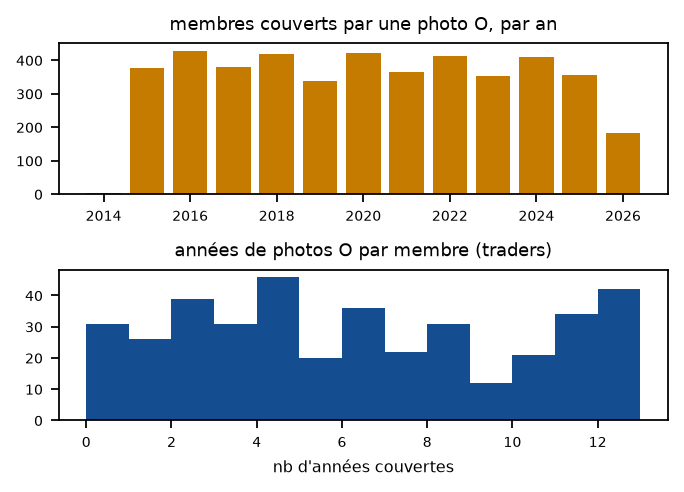

In [22]:
# Figure — la couverture des rapports annuels O (fig_10_couverture_O)
fig, axes = plt.subplots(2, 1, figsize=(FIGCOL, 3.1))
_par_an = (_o12.assign(an=_o12["filing_date"].dt.year).drop_duplicates(["bioguide", "an"])
           .groupby("an").size())
axes[0].bar(_par_an.index, _par_an.values, color="#c47b00")
axes[0].set_title("membres couverts par une photo O, par an")
axes[1].hist(info.loc[info["trade"], "n_annees_O"], bins=range(0, 14), color="#144d90")
axes[1].set_title("années de photos O par membre (traders)")
axes[1].set_xlabel("nb d'années couvertes")
plt.tight_layout(); plt.show()

### La discipline de dépôt — attendu vs observé

Le statut de chaque membre impose des dépôts : **arrivé** dans la fenêtre ⇒ une photo d'entrée H ·
**en mandat un 31/12** ⇒ un rapport annuel O, déposé l'année suivante · **parti** ⇒ un T, qui **tient
lieu de dernier rapport annuel**. Les mandats viennent du référentiel officiel *congress-legislators*
(YAML versionnés dans `reference/` — une donnée, pas une hypothèse). On mesure ici, membre par membre,
l'écart entre ce que la loi attend et ce que nos tables contiennent.

In [23]:
# Les mandats officiels des 900 : années où un rapport annuel O est attendu
import yaml
REF_DIR = os.path.abspath(os.path.join(V1T, "..", "..", "reference"))
_mandats = {}
for _f in ("legislators-current.yaml", "legislators-historical.yaml"):
    for _p in yaml.safe_load(open(os.path.join(REF_DIR, _f))):
        _t = [(x["start"], x["end"]) for x in _p["terms"] if x["type"] == "rep"]
        if _t:
            _mandats[_p["id"]["bioguide"]] = _t
assert reg14["bioguide"].isin(_mandats).all(), "membre du registre absent du référentiel"

def _annees_O_attendues(bid):
    # l'O couvre l'année civile Y (dépôt en Y+1) : attendu si en mandat au 31/12 de Y, Y ∈ 2013-2025
    return sorted({y for (s, e) in _mandats[bid] for y in range(2013, 2026) if s <= f"{y}-12-31" <= e})

regm = reg14.copy()
regm["annees_O_attendues"] = [_annees_O_attendues(b) for b in regm["bioguide"]]
regm["n_O_attendus"] = regm["annees_O_attendues"].str.len()
print(f"mandats : {len(regm)}/900 membres joints au référentiel · "
      f"{int(regm['n_O_attendus'].sum()):,} rapports annuels attendus au total · "
      f"{int((regm['n_O_attendus'] == 0).sum())} membres à 0 attendu (jamais en mandat un 31/12)")
display(regm[["bioguide", "quadrant", "n_O_attendus"]].head(3))

mandats : 900/900 membres joints au référentiel · 5,702 rapports annuels attendus au total · 7 membres à 0 attendu (jamais en mandat un 31/12)


,bioguide,quadrant,n_O_attendus
0,C001087,déjà-là restés,13
1,C001095,déjà-là partis,2
2,C001131,arrivés restés,3


In [24]:
# Validation croisée : le quadrant du registre (construit sur les DÉPÔTS) vs les mandats OFFICIELS
def _actif(bid, d):
    return any(s <= d <= e for s, e in _mandats[bid])
_deja = regm["bioguide"].apply(lambda b: _actif(b, "2014-01-01"))
_reste = regm["bioguide"].apply(lambda b: _actif(b, "2026-01-01"))
_quad_yaml = np.select([_deja & _reste, _deja & ~_reste, ~_deja & _reste, ~_deja & ~_reste],
                       ["déjà-là restés", "déjà-là partis", "arrivés restés", "cycle complet"], default="?")
_acc = (_quad_yaml == regm["quadrant"]).mean()
_dis = regm.loc[_quad_yaml != regm["quadrant"], ["bioguide", "quadrant"]].assign(mandats_officiels=_quad_yaml[_quad_yaml != regm["quadrant"]])
print(f"deux sources INDÉPENDANTES concordent à {_acc:.1%} — les {len(_dis)} désaccords sont des cas de frontière :")
display(_dis)
assert _acc > 0.95

deux sources INDÉPENDANTES concordent à 98.9% — les 10 désaccords sont des cas de frontière :


,bioguide,quadrant,mandats_officiels
96,M001245,arrivés restés,cycle complet
268,C001127,cycle complet,arrivés restés
356,F000485,arrivés restés,cycle complet
396,G000594,cycle complet,arrivés restés
405,G000607,arrivés restés,cycle complet
529,L000578,déjà-là partis,déjà-là restés
611,M001246,arrivés restés,cycle complet
732,S001157,déjà-là partis,déjà-là restés
751,S001193,déjà-là partis,déjà-là restés
863,G000596,cycle complet,arrivés restés


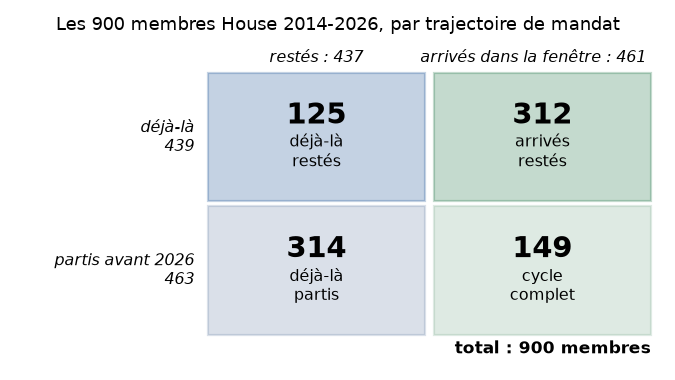

In [25]:
# Figure — le quadrant des 900, avec marges (fig_10_quadrant)
_q = regm["quadrant"].value_counts()
_dl_r, _dl_p = int(_q["déjà-là restés"]), int(_q["déjà-là partis"])
_ar_r, _cc = int(_q["arrivés restés"]), int(_q["cycle complet"])
fig, ax = plt.subplots(figsize=(FIGCOL, 2.4))
_cases = [(0, 1, _dl_r, "déjà-là\nrestés", "#144d90"), (1, 1, _ar_r, "arrivés\nrestés", "#146e3c"),
          (0, 0, _dl_p, "déjà-là\npartis", "#6d86a8"), (1, 0, _cc, "cycle\ncomplet", "#7fae92")]
for _x, _y, _n, _t, _c in _cases:
    ax.add_patch(plt.Rectangle((_x, _y), 0.96, 0.96, color=_c, alpha=0.25))
    ax.text(_x + 0.48, _y + 0.58, f"{_n}", ha="center", fontsize=13, weight="bold")
    ax.text(_x + 0.48, _y + 0.26, _t, ha="center", fontsize=7)
ax.text(-0.06, 1.48, f"déjà-là\n{_dl_r + _dl_p}", ha="right", va="center", fontsize=7, style="italic")
ax.text(-0.06, 0.48, f"partis avant 2026\n{_dl_p + _cc}", ha="right", va="center", fontsize=7, style="italic")
ax.text(0.48, 2.04, f"restés : {_dl_r + _ar_r}", ha="center", fontsize=7, style="italic")
ax.text(1.44, 2.04, f"arrivés dans la fenêtre : {_ar_r + _cc}", ha="center", fontsize=7, style="italic")
ax.text(1.96, -0.14, f"total : {len(regm)} membres", ha="right", fontsize=7.5, weight="bold")
ax.set_xlim(-0.85, 2.0); ax.set_ylim(-0.22, 2.18); ax.axis("off")
ax.set_title("Les 900 membres House 2014-2026, par trajectoire de mandat")
plt.tight_layout(); plt.show()

In [26]:
# Couverture des rapports annuels, membre par membre : O déposés ∪ T (qui tient lieu de dernier rapport)
_oT = ph12[ph12["filing_type"].isin(["O", "T"])].copy()
_oT["an_couvert"] = _oT["filing_date"].dt.year - 1        # convention : un rapport déposé en Y couvre Y-1
_vues = _oT.groupby("bioguide")["an_couvert"].agg(set)
regm["annees_vues"] = regm["bioguide"].map(_vues).apply(lambda s: s if isinstance(s, set) else set())
regm["n_O_couverts"] = [len(set(a) & v) for a, v in zip(regm["annees_O_attendues"], regm["annees_vues"])]
regm["taux_O"] = regm["n_O_couverts"] / regm["n_O_attendus"].replace(0, np.nan)
_tranches = pd.cut(regm.loc[regm["n_O_attendus"] > 0, "taux_O"], [-0.01, 0, 0.5, 0.999, 1.001],
                   labels=["0 %", "1-50 %", "51-99 %", "100 %"])
display(_tranches.value_counts().sort_index().to_frame("membres"))
print(f"taux de couverture médian : {regm['taux_O'].median():.0%} — médiane par quadrant :")
display(regm.groupby("quadrant")["taux_O"].median().map("{:.0%}".format).to_frame("taux médian"))

,membres
taux_O,
0 %,79
1-50 %,85
51-99 %,517
100 %,212


taux de couverture médian : 85% — médiane par quadrant :


,taux médian
quadrant,
arrivés restés,86%
cycle complet,100%
déjà-là partis,83%
déjà-là restés,92%


In [27]:
# LE tableau central : attendu vs observé, par trajectoire de mandat
_att_photo = regm["quadrant"].isin(["arrivés restés", "cycle complet"])   # arrivé ⇒ photo d'entrée attendue
_att_T = regm["quadrant"].isin(["déjà-là partis", "cycle complet"])       # parti ⇒ T attendu
_obs_photo = regm["a_photo_entree"].astype(bool)
_obs_T = regm["bioguide"].isin(set(ph12.loc[ph12["filing_type"] == "T", "bioguide"]))
_obs_O = regm["n_O_couverts"] > 0
_obs_P = regm["bioguide"].isin(set(cl.loc[cl["chamber"] == "house", "bioguide_id"]))
crosstab_central = (regm.assign(photo_obs=_obs_photo, photo_att=_att_photo, T_obs=_obs_T, T_att=_att_T,
                                O_obs=_obs_O, P_obs=_obs_P)
                    .groupby("quadrant")
                    .agg(n=("bioguide", "size"),
                         photo_entree=("photo_obs", "sum"), photo_attendue=("photo_att", "sum"),
                         T=("T_obs", "sum"), T_attendu=("T_att", "sum"),
                         O_1plus=("O_obs", "sum"), PTR_1plus=("P_obs", "sum"),
                         taux_O_med=("taux_O", "median"))
                    .reindex(["déjà-là restés", "déjà-là partis", "arrivés restés", "cycle complet"]))
crosstab_central.loc["TOTAL"] = crosstab_central.sum()
crosstab_central.loc["TOTAL", "taux_O_med"] = regm["taux_O"].median()
display(crosstab_central.astype({c: int for c in crosstab_central.columns if c != "taux_O_med"}, errors="ignore"))
assert int(crosstab_central.loc["TOTAL", "n"]) == 900
assert int(crosstab_central.loc["TOTAL", "photo_entree"]) == len(e15)
_manq_ph = int((_att_photo & ~_obs_photo).sum()); _manq_T = int((_att_T & ~_obs_T).sum())
_hors_ph = int((~_att_photo & _obs_photo).sum()); _hors_T = int((~_att_T & _obs_T).sum())
print(f"photo d'entrée : {int((_att_photo & _obs_photo).sum())}/{int(_att_photo.sum())} attendues présentes "
      f"→ {_manq_ph} manquantes · {_hors_ph} photos chez des non-attendus (journal)")
print(f"T : {int((_att_T & _obs_T).sum())}/{int(_att_T.sum())} attendus présents "
      f"→ {_manq_T} manquants · {_hors_T} T chez des restés (fins de mandat de bord)")

,n,photo_entree,photo_attendue,T,T_attendu,O_1plus,PTR_1plus,taux_O_med
quadrant,,,,,,,,
déjà-là restés,125,3,0,4,0,123,59,0.923077
déjà-là partis,314,1,0,253,314,299,100,0.833333
arrivés restés,312,200,312,3,0,250,108,0.857143
cycle complet,149,80,149,114,149,142,48,1.000000
TOTAL,900,284,461,374,463,814,315,0.846154


photo d'entrée : 280/461 attendues présentes → 181 manquantes · 4 photos chez des non-attendus (journal)
T : 367/463 attendus présents → 96 manquants · 7 T chez des restés (fins de mandat de bord)


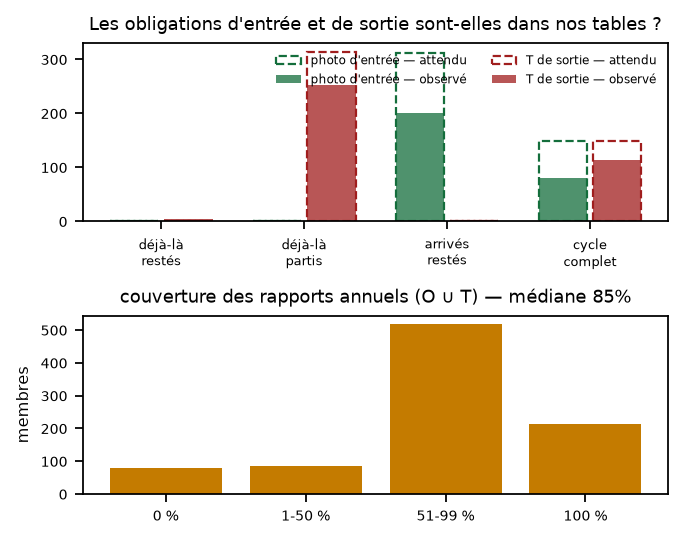

In [28]:
# Figure — attendu vs observé (fig_10_attendu_obs)
fig, axes = plt.subplots(2, 1, figsize=(FIGCOL, 3.4))
_quads = ["déjà-là restés", "déjà-là partis", "arrivés restés", "cycle complet"]
_x = np.arange(len(_quads))
for _dx, _obs_col, _att_col, _coul, _nom in [(-0.19, "photo_entree", "photo_attendue", "#146e3c", "photo d'entrée"),
                                             (0.19, "T", "T_attendu", "#a01e1e", "T de sortie")]:
    _o = crosstab_central.loc[_quads, _obs_col].astype(int)
    _a = crosstab_central.loc[_quads, _att_col].astype(int)
    axes[0].bar(_x + _dx, _a, width=0.34, fill=False, edgecolor=_coul, ls="--", label=f"{_nom} — attendu")
    axes[0].bar(_x + _dx, _o, width=0.34, color=_coul, alpha=0.75, label=f"{_nom} — observé")
axes[0].set_xticks(_x); axes[0].set_xticklabels([q.replace(" ", "\n") for q in _quads], fontsize=6)
axes[0].legend(frameon=False, fontsize=5.5, ncol=2)
axes[0].set_title("Les obligations d'entrée et de sortie sont-elles dans nos tables ?")
_tr = pd.cut(regm.loc[regm["n_O_attendus"] > 0, "taux_O"], [-0.01, 0, 0.5, 0.999, 1.001],
             labels=["0 %", "1-50 %", "51-99 %", "100 %"]).value_counts().sort_index()
axes[1].bar(_tr.index.astype(str), _tr.values, color="#c47b00")
axes[1].set_title(f"couverture des rapports annuels (O ∪ T) — médiane {regm['taux_O'].median():.0%}")
axes[1].set_ylabel("membres")
plt.tight_layout(); plt.show()

In [29]:
# Qui trade, par trajectoire de mandat — et déclarer sans trader
_s_ptr = set(df["bioguide_id"]); _s_oat = set(df_oat["bioguide_id"])
_statut = np.select([regm["bioguide"].isin(_s_ptr), regm["bioguide"].isin(_s_oat - _s_ptr)],
                    ["trade, vu par les PTR", "trade, vu SEULEMENT par les O/A/T"],
                    default="ne trade pas d'actions cotées")
trade_x_quad = pd.crosstab(regm["quadrant"], pd.Series(_statut, index=regm.index, name="statut"), margins=True)
display(trade_x_quad)
_nt = regm.loc[_statut == "ne trade pas d'actions cotées"]
_nt_O = int((_nt["n_O_couverts"] > 0).sum())
print(f"parmi les {len(_nt)} membres qui ne tradent pas : {_nt_O} ({_nt_O/len(_nt):.0%}) déposent quand même "
      f"des rapports annuels — ne pas trader n'est pas ne pas déclarer")

statut,ne trade pas d'actions cotées,"trade, vu SEULEMENT par les O/A/T","trade, vu par les PTR",All
quadrant,,,,
arrivés restés,171,36,105,312
cycle complet,85,16,48,149
déjà-là partis,196,23,95,314
déjà-là restés,57,11,57,125
All,509,86,305,900


parmi les 509 membres qui ne tradent pas : 444 (87%) déposent quand même des rapports annuels — ne pas trader n'est pas ne pas déclarer


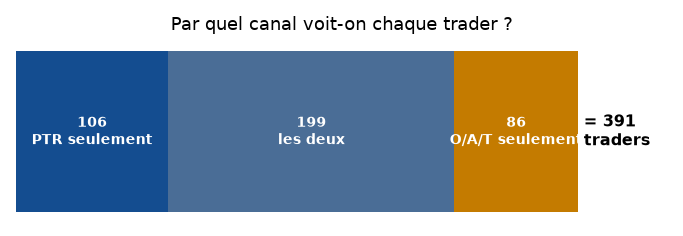

In [30]:
# Figure — les trois zones de la population qui trade (fig_10_trois_zones)
_z_ptr_seul = len(_s_ptr - _s_oat); _z_deux = len(_s_ptr & _s_oat); _z_oat_seul = len(_s_oat - _s_ptr)
assert _z_ptr_seul + _z_deux + _z_oat_seul == len(_s_ptr | _s_oat)
fig, ax = plt.subplots(figsize=(FIGCOL, 1.5))
_gauche = 0
for _n, _lab, _c in [(_z_ptr_seul, "PTR seulement", "#144d90"), (_z_deux, "les deux", "#4a6d96"),
                     (_z_oat_seul, "O/A/T seulement", "#c47b00")]:
    ax.barh(0, _n, left=_gauche, color=_c, height=0.55)
    ax.text(_gauche + _n / 2, 0, f"{_n}\n{_lab}", ha="center", va="center", fontsize=6.5,
            color="white", weight="bold")
    _gauche += _n
ax.text(_gauche + 4, 0, f"= {_gauche}\ntraders", va="center", fontsize=7, weight="bold")
ax.set_xlim(0, _gauche * 1.16); ax.axis("off")
ax.set_title("Par quel canal voit-on chaque trader ?")
plt.tight_layout(); plt.show()

In [31]:
# Bouclage : chaque membre a-t-il laissé AU MOINS une trace ? et qui sont les inconnus de la table 12 ?
_s_house_decl = set(cl.loc[cl["chamber"] == "house", "bioguide_id"])
_avec_doc = (regm["bioguide"].isin(set(ph12["bioguide"])) | regm["bioguide"].isin(_s_house_decl)
             | regm["bioguide"].isin(set(f16["bioguide"])))
_sans = regm.loc[~_avec_doc]
print(f"{len(_sans)} membres du registre sans AUCUN document (ni photo, ni PTR, ni O/A/T) — par quadrant :")
display(_sans["quadrant"].value_counts().to_frame("membres"))
_b12 = set(ph12["bioguide"].dropna())
print(f"réciproquement, la table 12 contient {len(_b12)} déposants : {len(_b12 & set(regm['bioguide']))} membres "
      f"du registre + {len(_b12 - set(regm['bioguide']))} candidats jamais élus (photos C sans mandat)")
assert len(_sans) + int(_avec_doc.sum()) == 900

18 membres du registre sans AUCUN document (ni photo, ni PTR, ni O/A/T) — par quadrant :


,membres
quadrant,
déjà-là partis,10
arrivés restés,5
déjà-là restés,2
cycle complet,1


réciproquement, la table 12 contient 887 déposants : 875 membres du registre + 12 candidats jamais élus (photos C sans mandat)


In [32]:
# Les délais administratifs : entrée en mandat → dépôt du H · fin de mandat → dépôt du T
_h = e15.loc[e15["type_photo"] == "H", ["bioguide", "filing_date"]].copy()
_h["delai_j"] = [min(((fd - pd.Timestamp(s)).days for s, e in _mandats[b] if pd.Timestamp(s) <= fd),
                     default=np.nan) for b, fd in zip(_h["bioguide"], _h["filing_date"])]
_t12 = ph12[ph12["filing_type"] == "T"].sort_values("filing_date").drop_duplicates("bioguide", keep="last")
_t12 = _t12[_t12["bioguide"].isin(_mandats)].copy()
_t12["delai_j"] = [min(((fd - pd.Timestamp(e)).days for s, e in _mandats[b]), key=abs, default=np.nan)
                   for b, fd in zip(_t12["bioguide"], _t12["filing_date"])]
print(f"entrée en mandat → dépôt du H : médiane {_h['delai_j'].median():.0f} j (n = {int(_h['delai_j'].notna().sum())}) — "
      f"la photo d'entrée arrive des MOIS après l'entrée")
print(f"fin de mandat → dépôt du T : médiane {_t12['delai_j'].median():.0f} j (n = {len(_t12)})")

entrée en mandat → dépôt du H : médiane 210 j (n = 252) — la photo d'entrée arrive des MOIS après l'entrée
fin de mandat → dépôt du T : médiane 34 j (n = 374)


In [33]:
# L'inventaire documentaire : combien de DOCUMENTS de chaque type (l'unité est le dépôt, pas la ligne)
_n_dep_p = cl.loc[cl["chamber"] == "house", ["bioguide_id", "disclosure_date"]].drop_duplicates().shape[0]
_n_docs_A = f16.loc[f16["filing_type"] == "A", "doc_id"].nunique()
inventaire = pd.DataFrame([
    ("H (photo d'entrée)", int((ph12["filing_type"] == "H").sum()), "documents"),
    ("C (photo de candidat)", int((ph12["filing_type"] == "C").sum()), "documents"),
    ("O (rapport annuel)", int((ph12["filing_type"] == "O").sum()), "documents"),
    ("T (photo de sortie)", int((ph12["filing_type"] == "T").sum()), "documents"),
    ("P (dépôts PTR)", _n_dep_p, "≈ paires (membre, date de divulgation) — le doc_id n'est pas dans la table clean"),
    ("A (amendements)", _n_docs_A, "documents PORTEURS de flux net seulement (table 16)"),
], columns=["type", "n", "unité exacte"]).set_index("type")
display(inventaire)
assert e15["bioguide"].is_unique and e15["doc_id"].is_unique
print(f"photos d'entrée retenues : {len(e15)} documents = {len(e15)} membres (1 photo par membre, asserté)")

,n,unité exacte
type,,
H (photo d'entrée),376,documents
C (photo de candidat),934,documents
O (rapport annuel),4447,documents
T (photo de sortie),378,documents
P (dépôts PTR),5571,"≈ paires (membre, date de divulgation) — le do..."
A (amendements),139,documents PORTEURS de flux net seulement (tabl...


photos d'entrée retenues : 284 documents = 284 membres (1 photo par membre, asserté)


choisi : Garret Graves (G000577) — cycle complet le mieux équipé (10 années O couvertes, 11 trades PTR)


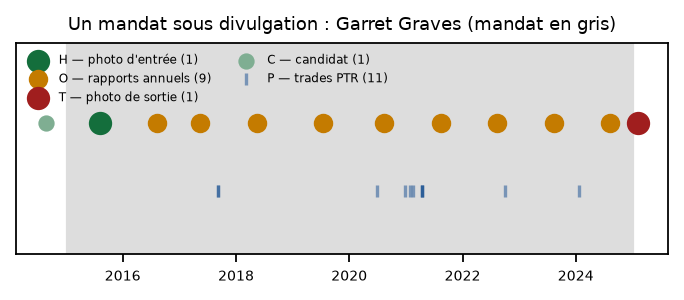

In [34]:
# Figure — la frise d'un membre réel (fig_10_frise_membre) : critère de choix AFFICHÉ
_cands = regm[(regm["quadrant"] == "cycle complet") & regm["a_photo_entree"].astype(bool)
              & regm["bioguide"].isin(set(ph12.loc[ph12["filing_type"] == "T", "bioguide"]))
              & (regm["n_O_couverts"] > 0) & regm["bioguide"].isin(set(df["bioguide_id"]))]
_cands = (_cands.assign(n_ptr=_cands["bioguide"].map(df.groupby("bioguide_id").size()))
          .sort_values(["n_O_couverts", "n_ptr"], ascending=False))
_bf = _cands.iloc[0]["bioguide"]
_nomf = df.loc[df["bioguide_id"] == _bf, "name"].iloc[0]
print(f"choisi : {_nomf} ({_bf}) — cycle complet le mieux équipé "
      f"({int(_cands.iloc[0]['n_O_couverts'])} années O couvertes, {int(_cands.iloc[0]['n_ptr'])} trades PTR)")
fig, ax = plt.subplots(figsize=(FIGCOL, 1.9))
for _s, _e in _mandats[_bf]:
    ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color="#dddddd", zorder=0)
_docs_f = ph12[ph12["bioguide"] == _bf]
_style = {"H": ("#146e3c", "H — photo d'entrée", 90), "O": ("#c47b00", "O — rapports annuels", 60),
          "T": ("#a01e1e", "T — photo de sortie", 90), "C": ("#7fae92", "C — candidat", 40)}
for _ft, (_c, _lab, _sz) in _style.items():
    _d = _docs_f.loc[_docs_f["filing_type"] == _ft, "filing_date"]
    if len(_d):
        ax.scatter(_d, [0.62] * len(_d), color=_c, s=_sz, zorder=3, label=f"{_lab} ({len(_d)})")
_ptr_d = df.loc[df["bioguide_id"] == _bf, "traded"]
ax.scatter(_ptr_d, np.full(len(_ptr_d), 0.3), marker="|", color="#144d90", s=28, alpha=0.5,
           label=f"P — trades PTR ({len(_ptr_d)})")
ax.set_ylim(0, 1); ax.set_yticks([])
ax.legend(frameon=False, fontsize=5.2, loc="upper left", ncol=2)
ax.set_title(f"Un mandat sous divulgation : {_nomf} (mandat en gris)")
plt.tight_layout(); plt.show()

### P1.1 Validation
Livre de comptes membres asserté ci-dessus (900 = PTR + oat-only + sans trade) · matrice = partition exhaustive du registre · non-régression PTR (107 976 / 305) vérifiée dans le livre · mandats officiels : 900/900 joints, quadrant concordant avec les dépôts à ~99 % (désaccords journalisés) · crosstab attendu/observé asserté (TOTAL = 900, photos = table 15) · trois zones sommées = population qui trade · bouclage : sans-document + avec-document = 900.

## P2 — Les transactions : ce que les PTR ratent

In [35]:
# LIVRE DE COMPTES O/A/T — chaque ligne écartée a une raison, et une seule (asserts)
_lc = f16.rename(columns={"bioguide": "bioguide_id", "transaction_date": "traded"}).copy()
_lc["ty"] = _lc["ticker"].map(to_yahoo)
_lc["op"] = _lc["sens"].map({"P": "buy", "S": "sell"})
_r_exch = _lc["op"].isna()
_r_date = ~_r_exch & ~_lc["traded"].dt.year.between(2013, 2026)
_r_mont = ~_r_exch & ~_r_date & ~(_lc["amount_mid_conventionnel"] > 0)
_avant  = ~(_r_exch | _r_date | _r_mont)
_r_faux = _avant & (_lc["classe"] == "faux_ticker")
_r_mone = _avant & (_lc["classe"] == "monetaire")
_r_fond = _avant & (_lc["classe"] == "fonds")
_nego   = _avant & (_lc["classe"] == "negociable")
_r_corr = _nego & _lc["ty"].isin(_corrompus)
_r_prix = _nego & ~_r_corr & ~_lc["ty"].isin(prices)
_okm    = _nego & ~_r_corr & ~_r_prix
_k = ["bioguide_id", "ty", "op", "traded"]
_cles_ptr = df.rename(columns={"ticker": "ty"})[_k]
_hit = _lc[_okm].merge(_cles_ptr.drop_duplicates().assign(_h=1), on=_k, how="left")["_h"].notna()
_n_coll_lignes = int(_hit.sum())
_n_appar = len(_lc[_okm].merge(_cles_ptr, on=_k, how="inner"))
_n_ok = int(_okm.sum()) - _n_coll_lignes
livre_oat = pd.DataFrame([
    ("lignes table 16 (trades O/A/T sans écho PTR côté v1)", len(_lc), ""),
    ("− exchanges (sens E : ni achat ni vente)", -int(_r_exch.sum()), ""),
    ("− date hors fenêtre 2013-2026 (dates corrompues)", -int(_r_date.sum()), ""),
    ("− sans montant exploitable", -int(_r_mont.sum()), ""),
    ("− FAUX TICKERS (codes de formulaire / libellés de compte)", -int(_r_faux.sum()),
     "EIF, SP, DC, JT… — jamais des instruments"),
    ("− monétaires (cash sweep : SPAXX, FDRXX…)", -int(_r_mone.sum()), "du cash, pas des trades"),
    ("− fonds mutuels (NAV, non négociables en bourse)", -int(_r_fond.sum()),
     "comptés, mais HORS moteur equity"),
    ("− ticker corrompu (garde-fou prix)", -int(_r_corr.sum()), ""),
    ("− aucune série de prix (après re-test de la failed-list)", -int(_r_prix.sum()),
     f"dont {int((_r_prix & _lc['asset_description'].astype(str).str.contains(RE_COMPTE, na=False)).sum())} libellés de compte (ticker probablement hérité)"),
    ("− en collision exacte avec un PTR de NOTRE table", -_n_coll_lignes,
     f"{_n_appar} appariements"),
    ("= TRADES O/A/T RETENUS (négociables, avec prix)", _n_ok, "provenance = oat"),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_oat)
assert len(_lc) - int(_r_exch.sum()) - int(_r_date.sum()) - int(_r_mont.sum()) \
       - int(_r_faux.sum()) - int(_r_mone.sum()) - int(_r_fond.sum()) \
       - int(_r_corr.sum()) - int(_r_prix.sum()) - _n_coll_lignes == _n_ok
assert _n_ok == len(df_oat) == int((df_uni["provenance"] == "oat").sum()), "livre ≠ df_oat"
print(f"✅ identité : {len(_lc):,} − marches = {_n_ok:,} = |df_oat| = lignes oat de F")

,n,note
marche,,
lignes table 16 (trades O/A/T sans écho PTR côté v1),26115,
− exchanges (sens E : ni achat ni vente),-221,
− date hors fenêtre 2013-2026 (dates corrompues),-14,
− sans montant exploitable,0,
− FAUX TICKERS (codes de formulaire / libellés de compte),-290,"EIF, SP, DC, JT… — jamais des instruments"
"− monétaires (cash sweep : SPAXX, FDRXX…)",-364,"du cash, pas des trades"
"− fonds mutuels (NAV, non négociables en bourse)",-10317,"comptés, mais HORS moteur equity"
− ticker corrompu (garde-fou prix),-39,
− aucune série de prix (après re-test de la failed-list),-1067,dont 698 libellés de compte (ticker probableme...


✅ identité : 26,115 − marches = 13,324 = |df_oat| = lignes oat de F


In [36]:
# RÉCONCILIATION avec l'ancien moteur (avant classification) : parmi les lignes écartées PAR NATURE
# (faux tickers, monétaires, fonds), combien ont une série de prix en cache ? L'ancien filtre « a un
# prix » les laissait ENTRER dans le moteur equity — un fonds a une NAV chez Yahoo, c'est le piège.
_exclu = _lc[_r_faux | _r_mone | _r_fond].copy()
_serie = _exclu["ty"].isin(_have_v2 | _have_ph)
print(f"écartées par la classe : {len(_exclu):,} lignes · {_exclu['amount_mid_conventionnel'].sum()/1e6:,.0f} M$")
print(f"dont {int(_serie.sum()):,} lignes ({_exclu.loc[_serie, 'amount_mid_conventionnel'].sum()/1e6:,.0f} M$) "
      f"avec une série en cache → l'ancien moteur les valorisait comme des actions ; v8 les écarte par nature")
display(_exclu.loc[_serie, "ticker"].value_counts().head(8).rename("lignes").to_frame())


écartées par la classe : 10,971 lignes · 1,010 M$
dont 8,439 lignes (627 M$) avec une série en cache → l'ancien moteur les valorisait comme des actions ; v8 les écarte par nature


,lignes
ticker,
MEIIX,106
FXAIX,69
FHARX,55
VWALX,52
GOFXX,50
FFFEX,47
PIMIX,44
DODGX,42


**Les délais de divulgation, recalculés ici** : quand l'information devient-elle publique ?

délai médian : PTR 27 j (q90 49) · O/A/T 373 j (q90 540)


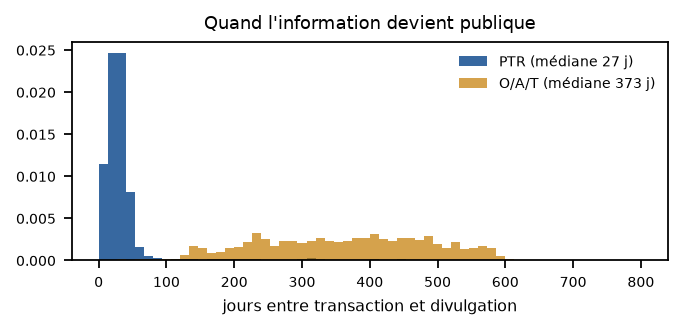

In [37]:
# Délais transaction → divulgation : PTR vs O/A/T (fig_10_delais)
_d_ptr = (cl.loc[cl["chamber"] == "house", ["transaction_date", "disclosure_date"]].dropna())
_d_ptr = (_d_ptr["disclosure_date"] - _d_ptr["transaction_date"]).dt.days
_d_ptr = _d_ptr[_d_ptr.between(0, 1500)]
_d_oat = (f16["disclosure_date"] - f16["transaction_date"]).dt.days
_d_oat = _d_oat[_d_oat.between(0, 1500)]
print(f"délai médian : PTR {_d_ptr.median():.0f} j (q90 {_d_ptr.quantile(.9):.0f}) · "
      f"O/A/T {_d_oat.median():.0f} j (q90 {_d_oat.quantile(.9):.0f})")
fig, ax = plt.subplots(figsize=(FIGCOL, 2.1))
ax.hist(_d_ptr, bins=60, range=(0, 800), color="#144d90", alpha=0.85, density=True,
        label=f"PTR (médiane {_d_ptr.median():.0f} j)")
ax.hist(_d_oat, bins=60, range=(0, 800), color="#c47b00", alpha=0.70, density=True,
        label=f"O/A/T (médiane {_d_oat.median():.0f} j)")
ax.legend(frameon=False); ax.set_xlabel("jours entre transaction et divulgation")
ax.set_title("Quand l'information devient publique")
plt.tight_layout(); plt.show()

In [38]:
# Qui apporte quoi : comptes par année × provenance × sens, et top apporteurs
display(pd.crosstab(df_uni["traded"].dt.year, [df_uni["provenance"], df_uni["op"]]).tail(13))
_top = (df_uni.assign(n=1)
        .pivot_table(index=["bioguide_id", "name"], columns="provenance", values="n",
                     aggfunc="sum", fill_value=0)
        .assign(part_oat=lambda d: d["oat"] / (d["oat"] + d["ptr"]))
        .sort_values("oat", ascending=False))
display(_top.head(8).style.format({"part_oat": "{:.0%}"}))

provenance   oat        ptr      
op           buy sell   buy  sell
traded                           
2014         392  339  3563  2780
2015         544  387  3116  3135
2016         306  320  2591  2273
2017         330  293  4664  3743
2018         432  460  5267  5062
2019         613  423  4604  4560
2020         666  589  5971  5722
2021         636  419  4825  4599
2022         749  534  5313  4895
2023        1237  918  3573  4192
2024        1059  833  3590  3280
2025         507  321  5487  6039
2026          12    4  2262  2368

,provenance,oat,ptr,part_oat
bioguide_id,name,,,
G000535,Luis V. Gutierrez,792,21,97%
M001135,Kathy Manning,542,729,43%
G000583,Josh Gottheimer,406,3054,12%
T000463,Michael R. Turner,367,2,99%
C001066,Kathy Castor,362,79,82%
W000800,Peter Welch,307,152,67%
B001303,Lisa Blunt Rochester,301,0,100%
P000034,Frank Pallone,237,12,95%


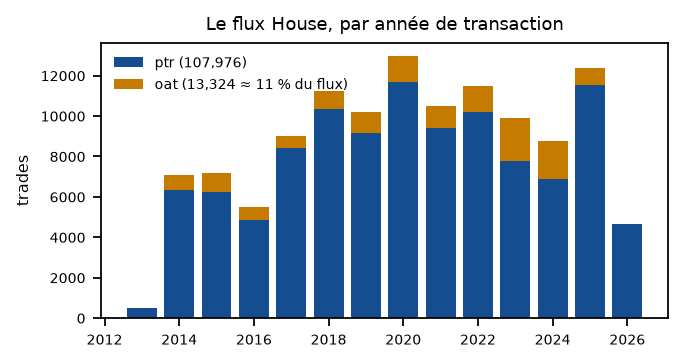

In [39]:
# Figure — le flux unifié par année (fig_10_flux)
_ct = pd.crosstab(df_uni["traded"].dt.year, df_uni["provenance"])
fig, ax = plt.subplots(figsize=(FIGCOL, 2.3))
ax.bar(_ct.index, _ct["ptr"], color="#144d90", label=f"ptr ({_ct['ptr'].sum():,})")
ax.bar(_ct.index, _ct["oat"], bottom=_ct["ptr"], color="#c47b00",
       label=f"oat ({_ct['oat'].sum():,} ≈ {100*_ct['oat'].sum()/len(df_uni):.0f} % du flux)")
ax.set_title("Le flux House, par année de transaction")
ax.set_ylabel("trades"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### P2.1 Validation
Livre de comptes O/A/T asserté (26 115 − marches = retenus = lignes oat de F) · les délais confirment la nature des sources : le PTR est un signal (~1 mois), l'annuel un enregistrement (~1 an).

## P3 — La reconstruction : le portefeuille de chaque membre

**G_zéro** (sans photo) : départ h = 0. **G_photo** : départ = portefeuille d'entrée, injecté au jour du **dépôt** :
$$h_0(m,i) = \tilde v_i / P_i(\tau(f_0)) \qquad \text{achat : } h \mathrel{+}= \tilde v/P(\tau(t)) \qquad \text{vente : } h \mathrel{-}= \min(q, h)$$

In [40]:
# h0_parts : une ligne par (membre, ticker) initialisable — q0 = mid / P(tau(f0))
def eff_price(tk, d):
    if tk not in prices: return None, None
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    return (s.index[pos], p) if np.isfinite(p) and p > 0 else (None, None)

# h0 est construit pour TOUS les membres à photo exploitable (la restriction se fait PAR RUN,
# au moteur : la photo n'est injectée que si le membre a >= 1 trade dans le flux du run)
_rows, _v_ok = [], 0.0
for _r in ph_ent.itertuples():
    _t0, _p = eff_price(_r.ticker_y, _r.filing_date)
    if _t0 is None: continue
    _rows.append(dict(bioguide_id=_r.bioguide, ticker=_r.ticker_y, q0=_r.mid / _p, t0=_t0))
    _v_ok += _r.mid
h0_parts = pd.DataFrame(_rows)
_v_tot = float(ph_ent["mid"].sum())
_n_traders_photo = len(set(h0_parts["bioguide_id"]) & _traders_uni)
print(f"h₀ : {h0_parts['bioguide_id'].nunique()} membres initialisables (sur 248 à photo exploitable) · "
      f"{len(h0_parts):,} lignes · {_v_ok/_v_tot*100:.1f} % de la valeur convertie en parts")
print(f"     dont {_n_traders_photo} TRADENT (∈ {len(_traders_uni)}) → injectables ; les autres n'ont rien à simuler")
display(h0_parts.head(3))

h₀ : 207 membres initialisables (sur 248 à photo exploitable) · 7,087 lignes · 85.8 % de la valeur convertie en parts
     dont 144 TRADENT (∈ 391) → injectables ; les autres n'ont rien à simuler


,bioguide_id,ticker,q0,t0
0,A000148,DMXF,134.225326,2021-07-29
1,A000148,DSI,403.457913,2021-07-29
2,A000148,EEMX,935.434903,2021-07-29


**Validation à la main** (hors moteur) puis livre de comptes photos.

In [41]:
for _bid in sorted(h0_parts["bioguide_id"].unique())[:2]:
    _l = h0_parts[h0_parts["bioguide_id"] == _bid].iloc[0]
    _src = ph_ent[(ph_ent["bioguide"] == _bid) & (ph_ent["ticker_y"] == _l["ticker"])].iloc[0]
    _t0, _p = eff_price(_l["ticker"], _src["filing_date"])
    assert abs(_l["q0"] - _src["mid"] / _p) < 1e-12 and _t0 == _l["t0"]
    print(f"{_bid} · {_l['ticker']:6s} : dépôt {_src['filing_date'].date()} → 1er coté {_t0.date()} · "
          f"ṽ = {_src['mid']:>9,.0f} $ ÷ P = {_p:8.2f} $ → q₀ = {_l['q0']:10.2f} ✅")

A000148 · DMXF   : dépôt 2021-07-29 → 1er coté 2021-07-29 · ṽ =     8,000 $ ÷ P =    59.60 $ → q₀ =     134.23 ✅
A000373 · AA     : dépôt 2015-05-14 → 1er coté 2015-05-14 · ṽ =     8,000 $ ÷ P =    30.58 $ → q₀ =     261.64 ✅


In [42]:
# LIVRE DE COMPTES PHOTOS — d'où sortent les injectées (asserts)
_ph_tous, _ph_expl = set(e15["bioguide"]), set(ph_ent["bioguide"])
_ph_init = set(h0_parts["bioguide_id"])
_ph_inj  = _ph_init & set(df_uni["bioguide_id"])
livre_ph = pd.DataFrame([
    ("photos d'entrée déposées (1 par membre)", len(_ph_tous), "252 H + 32 C"),
    ("− sans aucune ligne NÉGOCIABLE valorisée (fonds/monétaires/faux tickers exclus)", -(len(_ph_tous) - len(_ph_expl)), "non-coté, fonds, comptes"),
    ("= photos exploitables", len(_ph_expl), ""),
    ("− aucun prix chargeable au 1er jour coté ≥ dépôt", -(len(_ph_expl) - len(_ph_init)), ""),
    ("= membres initialisables (h₀ construit)", len(_ph_init), ""),
    ("   dont : tradent (∈ population) → INJECTÉS", len(_ph_inj), "B injecte le sous-ensemble PTR"),
    ("   dont : aucun trade → rien à simuler", len(_ph_init - _ph_inj), ""),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_ph)
assert len(_ph_tous) - (len(_ph_tous) - len(_ph_expl)) - (len(_ph_expl) - len(_ph_init)) == len(_ph_init)
assert len(_ph_inj) + len(_ph_init - _ph_inj) == len(_ph_init)
print(f"✅ {len(_ph_tous)} → {len(_ph_expl)} → {len(_ph_init)} → {len(_ph_inj)} injectées "
      f"(+ {len(_ph_init - _ph_inj)} sans trade)")

,n,note
marche,,
photos d'entrée déposées (1 par membre),284,252 H + 32 C
− sans aucune ligne NÉGOCIABLE valorisée (fonds/monétaires/faux tickers exclus),-61,"non-coté, fonds, comptes"
= photos exploitables,223,
− aucun prix chargeable au 1er jour coté ≥ dépôt,-16,
= membres initialisables (h₀ construit),207,
dont : tradent (∈ population) → INJECTÉS,144,B injecte le sous-ensemble PTR
dont : aucun trade → rien à simuler,63,


✅ 284 → 223 → 207 → 144 injectées (+ 63 sans trade)


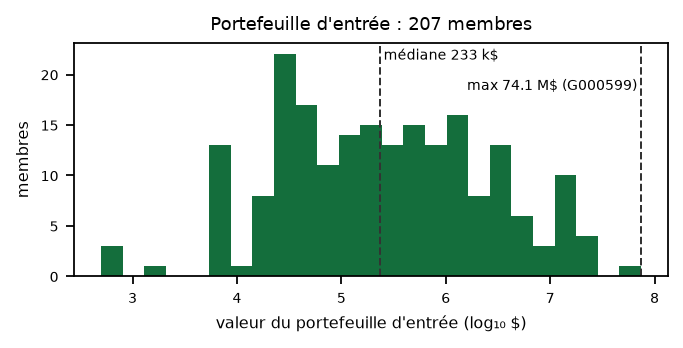

valeur h₀ : médiane 232,513 $ · max 74,104,236 $ (G000599)


In [43]:
# Figure — la valeur initialisée par membre (fig_10_h0_couverture)
_v0 = (h0_parts.assign(v=lambda d: [q * prices[t].loc[t0] for q, t, t0 in zip(d["q0"], d["ticker"], d["t0"])])
       .groupby("bioguide_id")["v"].sum())
fig, ax = plt.subplots(figsize=(FIGCOL, 2.2))
ax.hist(np.log10(_v0.clip(lower=1)), bins=25, color="#146e3c")
ax.axvline(np.log10(_v0.median()), ls="--", c="#333333", lw=0.9)
ax.text(np.log10(_v0.median()), ax.get_ylim()[1] * 0.93, f" médiane {_v0.median()/1e3:,.0f} k$", fontsize=6.5, ha="left")
ax.axvline(np.log10(_v0.max()), ls="--", c="#333333", lw=0.9)
ax.text(np.log10(_v0.max()), ax.get_ylim()[1] * 0.80, f"max {_v0.max()/1e6:,.1f} M$ ({_v0.idxmax()}) ", fontsize=6.5, ha="right")
ax.set_xlabel("valeur du portefeuille d'entrée (log₁₀ $)"); ax.set_ylabel("membres")
ax.set_title(f"Portefeuille d'entrée : {len(_v0)} membres")
plt.tight_layout(); plt.show()
print(f"valeur h₀ : médiane {_v0.median():,.0f} $ · max {_v0.max():,.0f} $ ({_v0.idxmax()})")

**Le moteur.** Rendement time-weighted sur les **parts de la veille** — un apport (photo ou achat) n'est
jamais une performance : $r_m(t) = \frac{\sum_i h_i(t-1) P_i(t)}{\sum_i h_i(t-1) P_i(t-1)} - 1$, borné ±50 %/j.

**Les 4 reconstructions** (même moteur, seules les données changent) :
| run | flux | photo |
|---|---|---|
| A (témoin) | ptr | non |
| B | ptr | oui |
| C | ptr ∪ oat | non |
| **D (adaptée)** | **ptr ∪ oat** | **oui** |

In [44]:
def member_shares(g, h0_rows=None):
    """trades d'un membre (+ h0 éventuel) -> (N parts par jour, masse tronquée en $)."""
    _h0 = ({r.ticker: (r.t0, r.q0) for r in h0_rows.itertuples()}
           if h0_rows is not None and len(h0_rows) else {})
    cols, tronque = {}, 0.0
    for tk in sorted(set(g["ticker"]) | set(_h0)):
        gt = g[g["ticker"] == tk]
        h, events = 0.0, {}
        rows = ([(pd.Timestamp(_h0[tk][0]), "h0", _h0[tk][1], None)] if tk in _h0 else [])
        rows += [(row["traded"], row["op"], None, row["size_usd"])
                 for _, row in gt.sort_values("traded").iterrows()]
        for d, op, q0, usd in sorted(rows, key=lambda x: (x[0], 0 if x[1] == "h0" else 1)):
            if op == "h0":
                events[d] = h = h + q0                    # d = tau(f0), prix déjà consommé en É4
                continue
            dd, p = eff_price(tk, d)
            if dd is None: continue
            qty = usd / p
            if op == "buy":
                h = h + qty
            else:
                tronque += (qty - min(qty, h)) * p
                h = h - min(qty, h)
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return (pd.DataFrame(cols) if cols else None), tronque

def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)
    num = (Nsh * P).sum(axis=1); den = (Nsh * P.shift(1)).sum(axis=1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index).clip(-0.5, 0.5)
    active = N.sum(axis=1) > 0
    if not active.any(): return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

In [45]:
def run_moteur(flux, use_h0):
    wfr, wft, tronq = {}, {}, {}
    _bids = set(flux["bioguide_id"])
    # la photo d'un membre n'est injectée que s'il a >= 1 trade dans CE flux (sinon rien à simuler)
    _h0g = ({b: g for b, g in h0_parts.groupby("bioguide_id") if b in _bids} if use_h0 else {})
    _fg = dict(tuple(flux.groupby("bioguide_id")))
    for bid in sorted(_bids):
        g = _fg.get(bid, flux.iloc[0:0])
        N, tr = member_shares(g, _h0g.get(bid))
        if N is None: continue
        r = daily_return(N)
        if len(r) < 2 or r.std() == 0: continue
        wfr[bid], tronq[bid] = r, tr
        wft[bid] = pd.to_datetime(np.sort(g["traded"].values))
    return wfr, wft, tronq, set(_h0g)

F_ptr = df_uni[df_uni["provenance"] == "ptr"]
runA = run_moteur(F_ptr, use_h0=False)
print(f"run A (témoin, ptr, départ zéro) : {len(runA[0])} membres avec série de rendement")

run A (témoin, ptr, départ zéro) : 226 membres avec série de rendement


In [46]:
runB = run_moteur(F_ptr, use_h0=True)
print(f"run B (+photo) : {len(runB[0])} membres | photos injectées : {len(runB[3])} | "
      f"tronqué {sum(runB[2].values())/1e6:,.0f} M$")

run B (+photo) : 257 membres | photos injectées : 115 | tronqué 897 M$


In [47]:
runC = run_moteur(df_uni, use_h0=False)
print(f"run C (+oat) : {len(runC[0])} membres | tronqué {sum(runC[2].values())/1e6:,.0f} M$")

run C (+oat) : 335 membres | tronqué 1,131 M$


In [48]:
runD = run_moteur(df_uni, use_h0=True)
print(f"run D (+photo +oat) : {len(runD[0])} membres | photos injectées : {len(runD[3])} "
      f"(les {len(runD[3]) - len(runB[3])} membres oat-only à photo sont enfin servis) | "
      f"tronqué {sum(runD[2].values())/1e6:,.0f} M$")

run D (+photo +oat) : 358 membres | photos injectées : 144 (les 29 membres oat-only à photo sont enfin servis) | tronqué 1,084 M$


In [49]:
RUNS = {"A (témoin)": runA, "B (+photo)": runB, "C (+oat)": runC, "D (adaptée)": runD}
recap6 = pd.DataFrame({k: dict(membres=len(r[0]), photos_injectees=len(r[3]),
                               tronque_MUSD=round(sum(r[2].values())/1e6))
                       for k, r in RUNS.items()}).T
display(recap6)

,membres,photos_injectees,tronque_MUSD
A (témoin),226,0,937
B (+photo),257,115,897
C (+oat),335,0,1131
D (adaptée),358,144,1084


### P3.1 Validation — trois preuves indépendantes

In [50]:
# (i) recalcul naïf du fil rouge (le membre à la plus grosse valeur initialisée)
FIL = _v0.loc[_v0.index.isin(runB[3])].idxmax()     # le plus gros h0 parmi les injectés de B
_g = F_ptr[F_ptr["bioguide_id"] == FIL]
N_fil, _ = member_shares(_g, h0_parts[h0_parts["bioguide_id"] == FIL])
r_moteur = runB[0][FIL]
_P = {tk: prices[tk] for tk in N_fil.columns}
_r_naif = {}
for _j in range(1, len(cal)):
    t0, t1 = cal[_j - 1], cal[_j]
    # np.nansum : un ticker sans prix ce jour-là est ignoré (même convention que le .sum() du moteur)
    num = np.nansum([N_fil[tk].iloc[_j - 1] * _P[tk].loc[t1] for tk in N_fil.columns])
    den = np.nansum([N_fil[tk].iloc[_j - 1] * _P[tk].loc[t0] for tk in N_fil.columns])
    if den > 0:
        _r_naif[t1] = max(min(num / den - 1.0, 0.5), -0.5)
_r_naif = pd.Series(_r_naif).reindex(r_moteur.index).fillna(0.0)
assert np.allclose(_r_naif.values, r_moteur.values, atol=1e-9)
print(f"(i) ✅ recalcul naïf de {FIL} : {len(r_moteur)} rendements identiques au moteur (atol 1e-9)")

(i) ✅ recalcul naïf de G000599 : 869 rendements identiques au moteur (atol 1e-9)


In [51]:
# (ii) apport ≠ performance : photo seule, zéro trade — r doit être nul le jour de l'injection
_h0_syn = h0_parts[h0_parts["bioguide_id"] == FIL].head(1)
N_syn, _ = member_shares(F_ptr.iloc[0:0], _h0_syn)
r_syn = daily_return(N_syn)
_t_inj = pd.Timestamp(_h0_syn["t0"].iloc[0])
assert abs(r_syn.loc[_t_inj]) < 1e-15
print(f"(ii) ✅ le jour de l'injection ({_t_inj.date()}), r = {r_syn.loc[_t_inj]:.0e} — l'apport ne crée rien ; "
      f"dès le lendemain, la position vit : r({r_syn.index[1].date()}) = {r_syn.iloc[1]*100:+.2f} %")

(ii) ✅ le jour de l'injection (2023-08-14), r = 0e+00 — l'apport ne crée rien ; dès le lendemain, la position vit : r(2023-08-15) = -0.79 %


In [52]:
# (iii) B ≡ A pour les membres sans photo (échantillon de 50)
_sans = [b for b in runA[0] if b not in runB[3]]
for _b in _sans[:50]:
    assert runB[0][_b].equals(runA[0][_b])
print(f"(iii) ✅ B ≡ A pour les membres sans photo injectée (contrôle sur 50/{len(_sans)})")

(iii) ✅ B ≡ A pour les membres sans photo injectée (contrôle sur 50/142)


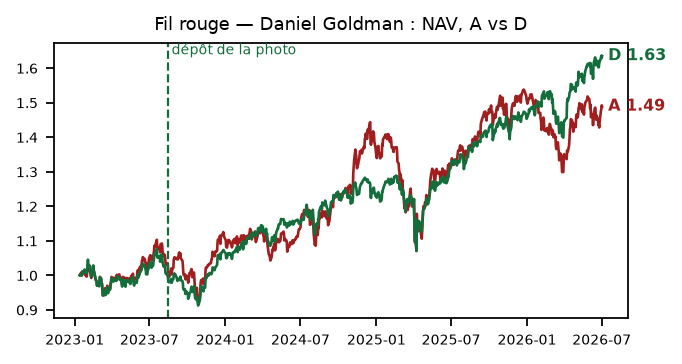

In [53]:
# Figure fil rouge — la NAV du membre, témoin vs adaptée (fig_10_filrouge)
_nom_fil = df.loc[df["bioguide_id"] == FIL, "name"].iloc[0] if (df["bioguide_id"] == FIL).any() else FIL
_f0 = h0_parts.loc[h0_parts["bioguide_id"] == FIL, "t0"].min()
fig, ax = plt.subplots(figsize=(FIGCOL, 2.3))
for _lbl, _run, _c in [("A", runA, "#a01e1e"), ("D", runD, "#146e3c")]:
    if FIL in _run[0]:
        _nv = (1 + _run[0][FIL]).cumprod()
        ax.plot(_nv, color=_c, lw=1.2)
        ax.text(_nv.index[-1], _nv.iloc[-1], f" {_lbl} {_nv.iloc[-1]:.2f}", color=_c, fontsize=7, va="center", weight="bold")
ax.axvline(_f0, ls="--", c="#146e3c", lw=1.0)
ax.text(_f0, ax.get_ylim()[1], " dépôt de la photo", color="#146e3c", fontsize=6.5, va="top")
ax.set_title(f"Fil rouge — {_nom_fil} : NAV, A vs D")
ax.tick_params(axis="x", labelrotation=0)
plt.tight_layout(); plt.show()

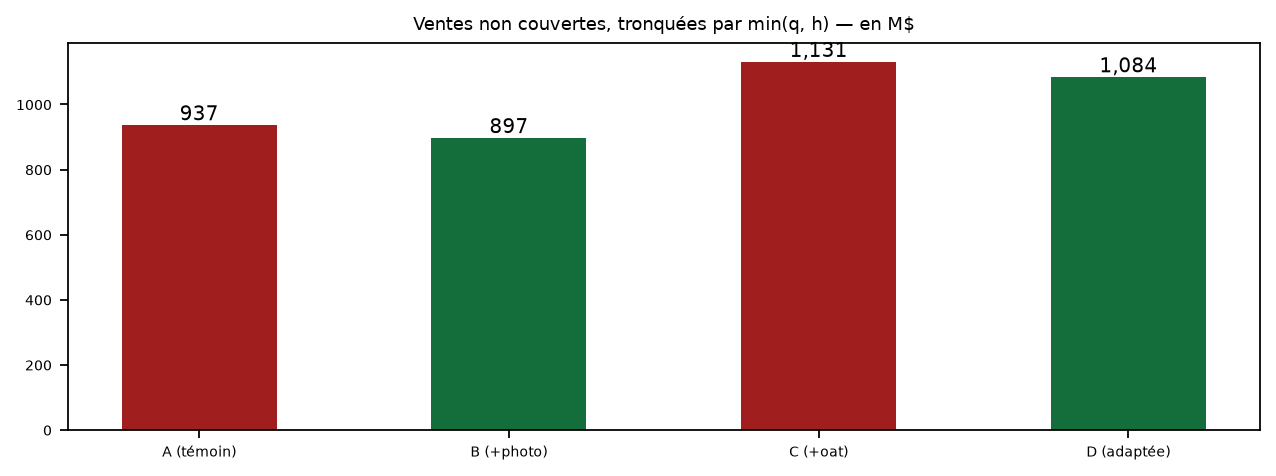

In [54]:
# Figure — la troncature des ventes fond quand la photo existe
_t_by = pd.DataFrame({k: pd.Series(r[2]) for k, r in RUNS.items()}).fillna(0.0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(4), _t_by.sum() / 1e6, color=["#a01e1e", "#146e3c", "#a01e1e", "#146e3c"],
       width=0.5, tick_label=list(RUNS))
for _i, _v in enumerate(_t_by.sum() / 1e6):
    ax.text(_i, _v, f"{_v:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Ventes non couvertes, tronquées par min(q, h) — en M$")
plt.tight_layout(); plt.show()

## P4 — La vérification : les rapports annuels jugent la reconstruction

Chaque photo **O** déclare le patrimoine au 31/12 ; notre moteur reconstruit h(t) jour par jour.
À la date de **dépôt** de chaque O (1er jour coté ≥ f), on confronte reconstruction et déclaration :

- **(a) positions** — précision = part des positions reconstruites qui sont déclarées ; rappel = part des positions déclarées qu'on a reconstruites ;
- **(b) valeurs** — sur les positions communes, h·P tombe-t-il dans la fourchette déclarée [v̲, v̄] ?

Calculé pour **A (témoin)** et **D (adaptée)** : si D colle mieux, les corrections améliorent la
reconstruction — indépendamment de toute performance boursière. Le **T** sert de vérification finale.

In [55]:
# Les photos d'un type donné, jointes à leurs lignes tickérisées/valorisées avec prix
def photos_type(ft):
    p = (ph12[ph12["filing_type"] == ft]
         .merge(h11, on="doc_id", suffixes=("", "_h"))
         .query("ticker == ticker and ~conteneur_nu")
         .assign(classe=lambda d: [classe_ligne(t, x) for t, x in zip(d["ticker"], d["asset_description"])])
         .query("classe == 'negociable'")   # v8 : equity vs equity — la reconstruction ne tient que des actions/ETF
         .assign(mid=lambda d: (d["value_lo"] + d["value_hi"]) / 2)
         .dropna(subset=["mid"]))
    p["ticker_y"] = p["ticker"].map(to_yahoo)
    p = p[p["ticker_y"].isin(prices)]
    return (p.groupby(["bioguide", "doc_id", "filing_date", "ticker_y"], as_index=False)
             .agg(lo=("value_lo", "sum"), hi=("value_hi", "sum")))

oph = photos_type("O")
print(f"photos O exploitables : {oph['doc_id'].nunique():,} documents · {oph['bioguide'].nunique()} membres · "
      f"{len(oph):,} lignes (tickérisées, valorisées, prix disponible)")
display(oph.head(3))

photos O exploitables : 1,945 documents · 394 membres · 31,073 lignes (tickérisées, valorisées, prix disponible)


,bioguide,doc_id,filing_date,ticker_y,lo,hi
0,A000055,10006023,2015-05-14,AMX,1001,15000.0
1,A000055,10006023,2015-05-14,GSK,1001,15000.0
2,A000055,10006023,2015-05-14,OPY,1001,15000.0


In [56]:
# Reconstruire les positions d'un membre à des dates données, dans une configuration donnée
_h0g_all = dict(tuple(h0_parts.groupby("bioguide_id")))
def positions_aux_dates(bid, dates, flux, use_h0):
    g = flux[flux["bioguide_id"] == bid]
    N, _ = member_shares(g, _h0g_all.get(bid) if use_h0 else None)
    if N is None:
        return {}
    out = {}
    for d in dates:
        pos = cal.searchsorted(d)
        if pos >= len(cal):
            continue
        row = N.loc[cal[pos]]
        out[d] = {tk: float(row[tk]) for tk in N.columns if row[tk] > 1e-9}
    return out

In [57]:
# La confrontation, photo par photo, pour une configuration
def confronter(nom, flux, use_h0, photos):
    _g = dict(tuple(photos.groupby("bioguide")))
    _bids = sorted(set(_g) & set(flux["bioguide_id"].unique()))
    rows = []
    for _bid in _bids:
        _pm = _g[_bid]
        _dates = sorted(_pm["filing_date"].unique())
        _posm = positions_aux_dates(_bid, _dates, flux, use_h0)
        for _d in _dates:
            if _d not in _posm:
                continue
            _pd_ = _pm[_pm["filing_date"] == _d]
            _decl, _rec = set(_pd_["ticker_y"]), set(_posm[_d])
            _com = _decl & _rec
            _t = cal[cal.searchsorted(_d)]
            _nf = 0
            for _tk in _com:
                _v = _posm[_d][_tk] * prices[_tk].loc[_t]
                _b = _pd_.loc[_pd_["ticker_y"] == _tk, ["lo", "hi"]].iloc[0]
                if _b["lo"] * 0.999 <= _v <= _b["hi"] * 1.001:
                    _nf += 1
            rows.append(dict(run=nom, bioguide=_bid, annee=_d.year,
                             n_decl=len(_decl), n_rec=len(_rec), n_com=len(_com),
                             precision=len(_com) / len(_rec) if _rec else np.nan,
                             rappel=len(_com) / len(_decl) if _decl else np.nan,
                             n_fourchette=_nf))
    return pd.DataFrame(rows)

verif = pd.concat([confronter("A (témoin)", F_ptr, False, oph),
                   confronter("D (adaptée)", df_uni, True, oph)], ignore_index=True)
print(f"confrontations : {len(verif):,} (photo O × run)")
display(verif.head(4))

confrontations : 3,001 (photo O × run)


,run,bioguide,annee,n_decl,n_rec,n_com,precision,rappel,n_fourchette
0,A (témoin),A000055,2015,3,0,0,NaN,0.0,0
1,A (témoin),A000055,2016,4,0,0,NaN,0.0,0
2,A (témoin),A000055,2017,4,0,0,NaN,0.0,0
3,A (témoin),A000055,2018,4,0,0,NaN,0.0,0


In [58]:
# Agrégats et verdict : la reconstruction adaptée colle-t-elle mieux aux déclarations ?
agg4 = (verif.groupby("run")[["precision", "rappel"]].median()
        .join(verif.groupby("run").apply(lambda d: d["n_fourchette"].sum() / max(d["n_com"].sum(), 1),
                                         include_groups=False).rename("part_valeurs_en_fourchette"))
        .join(verif.groupby("run").size().rename("n_photos")))
display(agg4.round(3))
_pA, _pD = agg4.loc["A (témoin)"], agg4.loc["D (adaptée)"]
print(f"verdict reconstruction : rappel médian {_pA['rappel']:.0%} (A) → {_pD['rappel']:.0%} (D) · "
      f"précision {_pA['precision']:.0%} → {_pD['precision']:.0%} · "
      f"valeurs en fourchette {_pA['part_valeurs_en_fourchette']:.0%} → {_pD['part_valeurs_en_fourchette']:.0%}")

,precision,rappel,part_valeurs_en_fourchette,n_photos
run,,,,
A (témoin),0.587,0.083,0.538,1376
D (adaptée),0.600,0.579,0.536,1625


verdict reconstruction : rappel médian 8% (A) → 58% (D) · précision 59% → 60% · valeurs en fourchette 54% → 54%


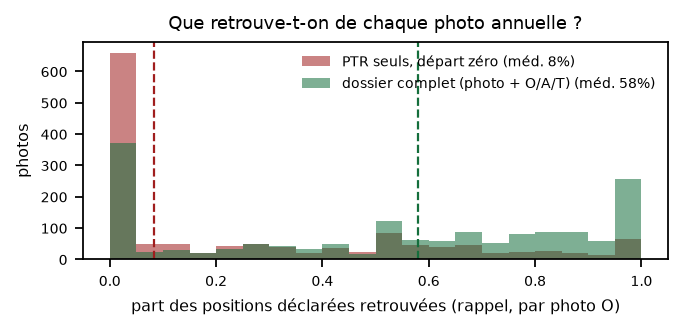

In [59]:
# Distribution du rappel, photo par photo — étiquettes par SOURCES (fig_10_verif_dist)
_lab = {"A (témoin)": "PTR seuls, départ zéro", "D (adaptée)": "dossier complet (photo + O/A/T)"}
fig, ax = plt.subplots(figsize=(FIGCOL, 2.1))
for _run, _col in [("A (témoin)", "#a01e1e"), ("D (adaptée)", "#146e3c")]:
    _r = verif.loc[verif["run"] == _run, "rappel"].fillna(0)
    ax.hist(_r, bins=np.linspace(0, 1, 21), alpha=0.55, color=_col,
            label=f"{_lab[_run]} (méd. {_r.median():.0%})")
    ax.axvline(_r.median(), color=_col, lw=1, ls="--")
ax.set_xlabel("part des positions déclarées retrouvées (rappel, par photo O)")
ax.set_ylabel("photos")
ax.set_title("Que retrouve-t-on de chaque photo annuelle ?")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

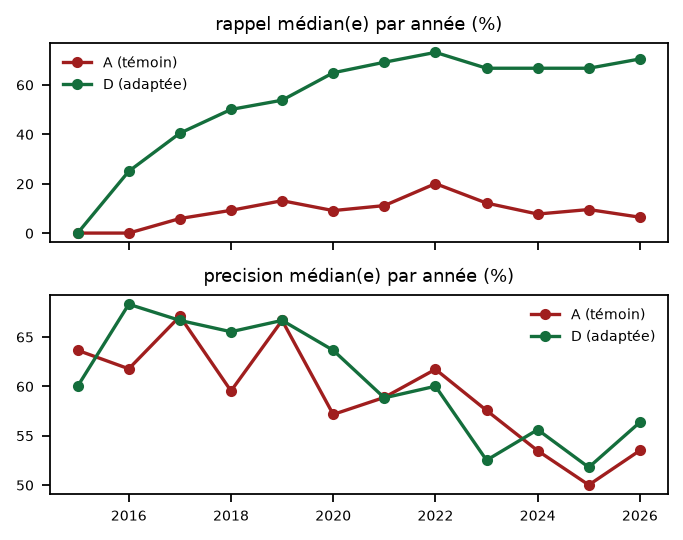

In [60]:
# Figure — la vérification année par année (fig_10_verif_O)
_ag = verif.groupby(["run", "annee"])[["precision", "rappel"]].median().reset_index()
fig, axes = plt.subplots(2, 1, figsize=(FIGCOL, 3.4), sharex=True)
for _ax, _m in zip(axes, ["rappel", "precision"]):
    for _r, _c in [("A (témoin)", "#a01e1e"), ("D (adaptée)", "#146e3c")]:
        _s = _ag[_ag["run"] == _r]
        _ax.plot(_s["annee"], _s[_m] * 100, marker="o", ms=4, color=_c, label=_r)
    _ax.set_title(f"{_m} médian(e) par année (%)"); _ax.legend(frameon=False, loc="best")
plt.tight_layout(); plt.show()

In [61]:
# Le T — la photo de sortie, en réconciliation finale (configuration D uniquement)
verif_T = confronter("D (adaptée)", df_uni, True, photos_type("T"))
print(f"photos T confrontées : {len(verif_T):,} · rappel médian {verif_T['rappel'].median():.0%} · "
      f"précision médiane {verif_T['precision'].median():.0%}")

photos T confrontées : 108 · rappel médian 64% · précision médiane 59%


### P4.1 Validation — une photo recomptée à la main

In [62]:
# Une photo O recomptée hors des fonctions : le membre à photos le plus actif du run D
_bid4 = verif.loc[verif["run"] == "D (adaptée)"].groupby("bioguide").size().idxmax()
_ph4 = oph[oph["bioguide"] == _bid4].sort_values("filing_date")
_d4 = _ph4["filing_date"].iloc[-1]
_pos4 = positions_aux_dates(_bid4, [_d4], df_uni, True)[_d4]
_decl4 = set(_ph4.loc[_ph4["filing_date"] == _d4, "ticker_y"])
_prec4 = len(_decl4 & set(_pos4)) / len(_pos4)
_rap4 = len(_decl4 & set(_pos4)) / len(_decl4)
_ligne4 = verif[(verif["run"] == "D (adaptée)") & (verif["bioguide"] == _bid4)
                & (verif["annee"] == _d4.year)].iloc[-1]
assert abs(_prec4 - _ligne4["precision"]) < 1e-12 and abs(_rap4 - _ligne4["rappel"]) < 1e-12
print(f"✅ {_bid4}, photo O déposée {_d4.date()} : {len(_decl4)} positions déclarées, {len(_pos4)} reconstruites, "
      f"{len(_decl4 & set(_pos4))} communes → précision {_prec4:.0%}, rappel {_rap4:.0%} ≡ table verif")

✅ C001066, photo O déposée 2026-05-24 : 18 positions déclarées, 35 reconstruites, 16 communes → précision 46%, rappel 89% ≡ table verif


**Limites de l'exercice, dites franchement** : clés ticker uniquement (le non-coté déclaré est hors jeu) ·
fourchettes larges (la métrique valeurs est indulgente par construction) · la photo décrit le 31/12 mais on la
confronte au jour du dépôt (l'écart de dates ajoute du bruit dans les DEUX sens, pour A comme pour D) ·
les A (amendements) ne sont pas re-fusionnés aux O ici.

## P5 — La stratégie : le backtest adapté

Classement au **Sharpe** (éligible : n_jours ≥ 126 et Sharpe > 0,4), **K walk-forward** (grille 4-20, départ 10),
poids **1/K** et inverse-vol, tenue 1 an, parts autofinancées ; évaluation par années civiles vs SPY
(n = 11, seuil t₁₀ ≈ 1,81).

In [63]:
def classement_sharpe(Y, wfr, min_days=126, min_sharpe=0.4):
    """Éligibles (n_jours ≥ 126 ET Sharpe > 0,4 — règle du 05b Partie II), classés par Sharpe décroissant."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wfr.items():
        rr = r.loc[:yend]
        if len(rr) < min_days or rr.std() == 0:
            continue
        s = rr.mean() / rr.std() * np.sqrt(252)
        if s <= min_sharpe:
            continue
        rows.append((bid, s))
    rows.sort(key=lambda x: -x[1])
    return [b for b, _ in rows]

def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: (1 + r[r.index.year == y]).prod() - (1 + b[b.index.year == y]).prod()
                      for y in sorted(set(r.index.year))})

def alpha_beta(r):
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = alpha / se * np.sqrt(252) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, t_appr=appr * np.sqrt(len(d) / 252))

In [64]:
def strategie_kwf(wfr, poids="1/K", K_GRID=range(4, 21), K_INIT=10):
    """Sharpe · K walk-forward · poids ∈ {1/K, inv-vol}. Retourne r_strat, K*(Y), sélections, classements."""
    navk = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in wfr.items()})
    cls = {Y: classement_sharpe(Y, wfr) for Y in range(2015, 2026)}
    def w_of(bids, Y):
        if poids == "1/K":
            return np.ones(len(bids)) / len(bids)
        yend = pd.Timestamp(f"{Y}-12-31")
        iv = np.array([1.0 / wfr[b].loc[:yend].std() for b in bids])
        return iv / iv.sum()
    def bloc(Y, K):                                    # rendements du bloc tenu l'année Y+1
        bids = cls[Y][:K]
        idx = cal[cal.year == Y + 1]
        if not bids or not len(idx): return None
        w = w_of(bids, Y)
        assert abs(w.sum() - 1.0) < 1e-9               # autofinancement : les poids somment à 1
        tR = cal[cal.get_loc(idx[0]) - 1]
        nbr = pd.Series(w / navk.loc[tR, bids].values, index=bids)
        nav = navk.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] - 1.0
        return r
    xs = {(K, Y + 1): yearly_excess(b).iloc[0]
          for K in K_GRID for Y in range(2015, 2026) if (b := bloc(Y, K)) is not None}
    rets, kpath, sels = [], {}, {}
    for Y in range(2015, 2026):
        deja = [y for y in range(2016, Y + 1)]         # années tenues, terminées à la coupe 31/12/Y
        K = K_INIT if not deja else max(K_GRID, key=lambda k: sum(xs.get((k, y), 0.0) for y in deja))
        b = bloc(Y, K)
        if b is None: continue
        kpath[Y + 1], sels[Y + 1] = K, cls[Y][:K]
        rets.append(b)
    if not rets:
        return dict(r=pd.Series(dtype=float), kpath=kpath, sels=sels, xs=xs, cls=cls)
    return dict(r=pd.concat(rets).sort_index(), kpath=kpath, sels=sels, xs=xs, cls=cls)

In [65]:
# LE tableau du notebook : 4 runs × 2 poids
def ligne(r):
    e = yearly_excess(r); n = len(e)
    if n < 2: return dict(exces_an=np.nan, t=np.nan, gagnantes=f"-/{n}", beta=np.nan,
                          alpha_ann=np.nan, t_appr=np.nan)
    ab = alpha_beta(r)
    return dict(exces_an=e.mean(), t=e.mean() / e.std(ddof=1) * np.sqrt(n),
                gagnantes=f"{int((e > 0).sum())}/{n}", **ab)

POIDS = ["1/K", "inv-vol"]
strat = {(k, p): strategie_kwf(r[0], poids=p) for k, r in RUNS.items() for p in POIDS}
tab7 = pd.DataFrame({f"{k} · {p}": ligne(s["r"]) for (k, p), s in strat.items()}).T
print(f"Sharpe (éligible : n_jours ≥ 126 et Sharpe > 0,4) · K walk-forward (4-20, départ 10) — "
      f"{len(yearly_excess(strat[('A (témoin)', '1/K')]['r']))} années civiles, seuil t₁₀ ≈ 1,81")
display(tab7.round(3))

Sharpe (éligible : n_jours ≥ 126 et Sharpe > 0,4) · K walk-forward (4-20, départ 10) — 11 années civiles, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
A (témoin) · 1/K,0.008574,0.365653,4/11,0.988663,0.006169,0.283756
A (témoin) · inv-vol,-0.002704,-0.113275,4/11,1.001319,-0.005213,-0.271197
B (+photo) · 1/K,0.072074,0.883001,5/11,0.986025,0.05489,1.572291
B (+photo) · inv-vol,0.03822,0.685733,5/11,0.943782,0.036959,1.410282
C (+oat) · 1/K,-0.001336,-0.082758,4/11,0.910003,0.010599,0.642375
C (+oat) · inv-vol,-0.017487,-0.914413,4/11,0.832197,0.007173,0.408847
D (adaptée) · 1/K,0.002231,0.12569,6/11,0.927221,0.012074,0.69095
D (adaptée) · inv-vol,-0.014535,-0.784562,4/11,0.843263,0.008653,0.514598


**Les effets, testés en différences appariées** (mêmes années, même SPY — plus puissant que les t marginaux) :

In [66]:
# Effets appariés année par année (poids 1/K) : photo (B−A), oat (C−A), interaction
X9 = pd.DataFrame({k.split(" ")[0]: yearly_excess(strat[(k, "1/K")]["r"]) for k in RUNS})
display(X9.round(4))
_eff = {"photo (B−A)": X9["B"] - X9["A"], "oat (C−A)": X9["C"] - X9["A"],
        "interaction (D−B−C+A)": X9["D"] - X9["B"] - X9["C"] + X9["A"]}
tab_eff = pd.DataFrame({n: {"moy_pct_an": 100 * d.mean(),
                            "t_apparie": d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))}
                        for n, d in _eff.items()}).T
display(tab_eff.round(2))

,A,B,C,D
2016,-0.0630,-0.0630,-0.0597,-0.0597
2017,0.1258,0.1258,0.0173,-0.0191
2018,-0.0069,-0.0289,-0.0137,0.0009
2019,-0.0276,-0.0276,0.0506,0.0931
2020,0.0338,0.8695,-0.0642,0.0547
2021,-0.0645,-0.0693,-0.0220,-0.0672
2022,-0.0631,0.0033,0.0374,0.0238
2023,0.0339,-0.0348,0.1152,0.0837
2024,0.1709,-0.0566,-0.0447,-0.0831
2025,-0.0267,0.0548,-0.0022,-0.0086


,moy_pct_an,t_apparie
photo (B−A),6.35,0.78
oat (C−A),-0.99,-0.34
interaction (D−B−C+A),-5.99,-0.86


In [67]:
# Le chemin K*(Y) et le nombre d'éligibles par coupe
kpaths = pd.DataFrame({f"{k} · {p}": s["kpath"] for (k, p), s in strat.items()}).T
kpaths.index.name = "K* pour l'année tenue →"
display(kpaths)
elig7 = pd.DataFrame({k: {Y: len(strat[(k, "1/K")]["cls"][Y]) for Y in range(2015, 2026)}
                      for k in RUNS}).T
elig7.index.name = "éligibles à la coupe →"
display(elig7)

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
K* pour l'année tenue →,,,,,,,,,,,
A (témoin) · 1/K,10,4,4,4,13,12,4,5,5,4,4
A (témoin) · inv-vol,10,4,4,4,4,12,4,12,4,4,4
B (+photo) · 1/K,10,4,4,4,4,4,4,4,4,4,4
B (+photo) · inv-vol,10,4,4,4,4,4,4,4,4,4,4
C (+oat) · 1/K,10,17,5,4,5,8,8,6,6,6,6
C (+oat) · inv-vol,10,17,5,5,5,6,6,6,6,6,6
D (adaptée) · 1/K,10,17,5,5,5,6,5,5,6,6,6
D (adaptée) · inv-vol,10,17,5,5,5,6,6,6,6,6,6


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
éligibles à la coupe →,,,,,,,,,,,
A (témoin),42,61,92,76,123,128,152,121,152,174,184
B (+photo),43,67,104,82,140,139,168,136,170,200,215
C (+oat),53,79,119,91,162,169,203,153,211,255,278
D (adaptée),54,84,130,95,176,177,216,164,223,273,299


### P5.1 Validation — un bloc de stratégie recalculé à la main

In [68]:
_s = strat[("A (témoin)", "1/K")]
_wfr = RUNS["A (témoin)"][0]
_navk = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in _wfr.items()})
_bids = classement_sharpe(2017, _wfr)[:10]
_idx = cal[cal.year == 2018]; _tR = cal[cal.get_loc(_idx[0]) - 1]
_nbr = {b: (1.0 / len(_bids)) / _navk.loc[_tR, b] for b in _bids}
_nav_fin = sum(_nbr[b] * _navk.loc[_idx[-1], b] for b in _bids)
_spy_2018 = (1 + r_spy[r_spy.index.year == 2018].fillna(0)).prod()
_x_main = (_nav_fin - 1.0) - (_spy_2018 - 1.0)
assert abs(_x_main - _s["xs"][(10, 2018)]) < 1e-12
print(f"✅ bloc 2018, K=10 : excès recalculé à la main = {_x_main*100:+.2f} % ≡ moteur "
      f"({_s['xs'][(10, 2018)]*100:+.2f} %)")

✅ bloc 2018, K=10 : excès recalculé à la main = -3.20 % ≡ moteur (-3.20 %)


**Les résultats en figures.**

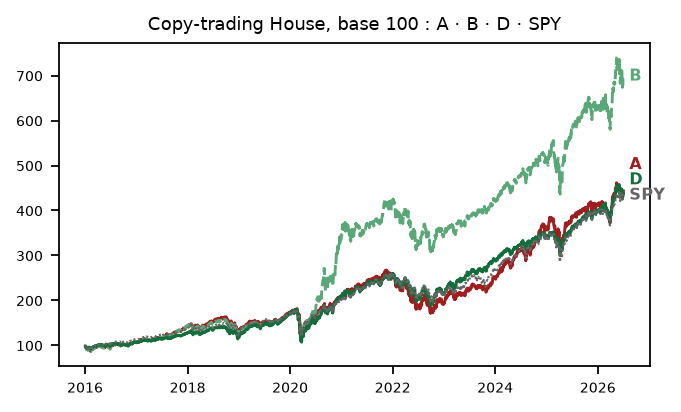

In [69]:
# Figure — NAV de la stratégie (poids 1/K) : A, B, D, SPY — base 100 (fig_10_nav)
_rs9 = {"A": ("A (témoin)", "#a01e1e", "-"), "B": ("B (+photo)", "#5aa878", "--"),
        "D": ("D (adaptée)", "#146e3c", "-")}
_i0 = max(strat[(v[0], "1/K")]["r"].index[0] for v in _rs9.values())
fig, ax = plt.subplots(figsize=(FIGCOL, 2.6))
_fins = []
for _k, (_lbl, _c, _ls) in _rs9.items():
    _r = strat[(_lbl, "1/K")]["r"]
    _n = (1 + _r[_r.index >= _i0]).cumprod() * 100
    ax.plot(_n, color=_c, lw=1.3, ls=_ls)
    _fins.append([_k, _c, _n.index[-1], float(_n.iloc[-1])])
_spy_n = (1 + r_spy[r_spy.index >= _i0].fillna(0)).cumprod() * 100
ax.plot(_spy_n, color="#666666", lw=1.0, ls=":")
_fins.append(["SPY", "#666666", _spy_n.index[-1], float(_spy_n.iloc[-1])])
_fins.sort(key=lambda f: f[3])
for _j in range(1, len(_fins)):
    if _fins[_j][3] - _fins[_j - 1][3] < 34:
        _fins[_j][3] = _fins[_j - 1][3] + 34
for _k, _c, _xf, _yf in _fins:
    ax.text(_xf, _yf, f" {_k}", color=_c, fontsize=7, va="center", weight="bold")
ax.set_title("Copy-trading House, base 100 : A · B · D · SPY")
plt.tight_layout(); plt.show()

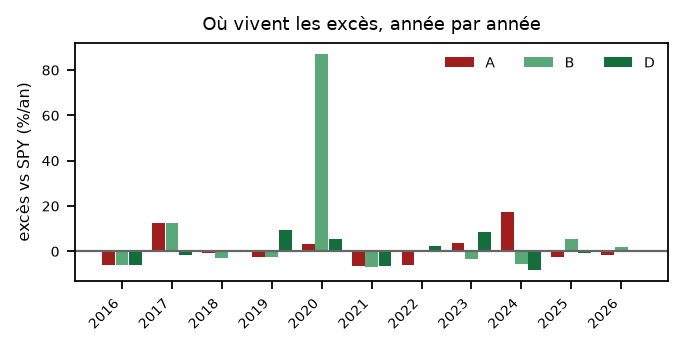

In [70]:
# Figure — l'excès annuel vs SPY, année par année (fig_10_exces_annuel)
_xa = np.arange(len(X9)); _w = 0.27
fig, ax = plt.subplots(figsize=(FIGCOL, 2.2))
for _off, _k, _c in [(-_w, "A", "#a01e1e"), (0.0, "B", "#5aa878"), (_w, "D", "#146e3c")]:
    ax.bar(_xa + _off, 100 * X9[_k], _w * 0.95, color=_c, label=_k)
ax.axhline(0, color="#666666", lw=1)
ax.set_xticks(_xa); ax.set_xticklabels(X9.index, rotation=45, ha="right")
ax.set_ylabel("excès vs SPY (%/an)"); ax.legend(frameon=False, ncol=3)
ax.set_title("Où vivent les excès, année par année")
plt.tight_layout(); plt.show()

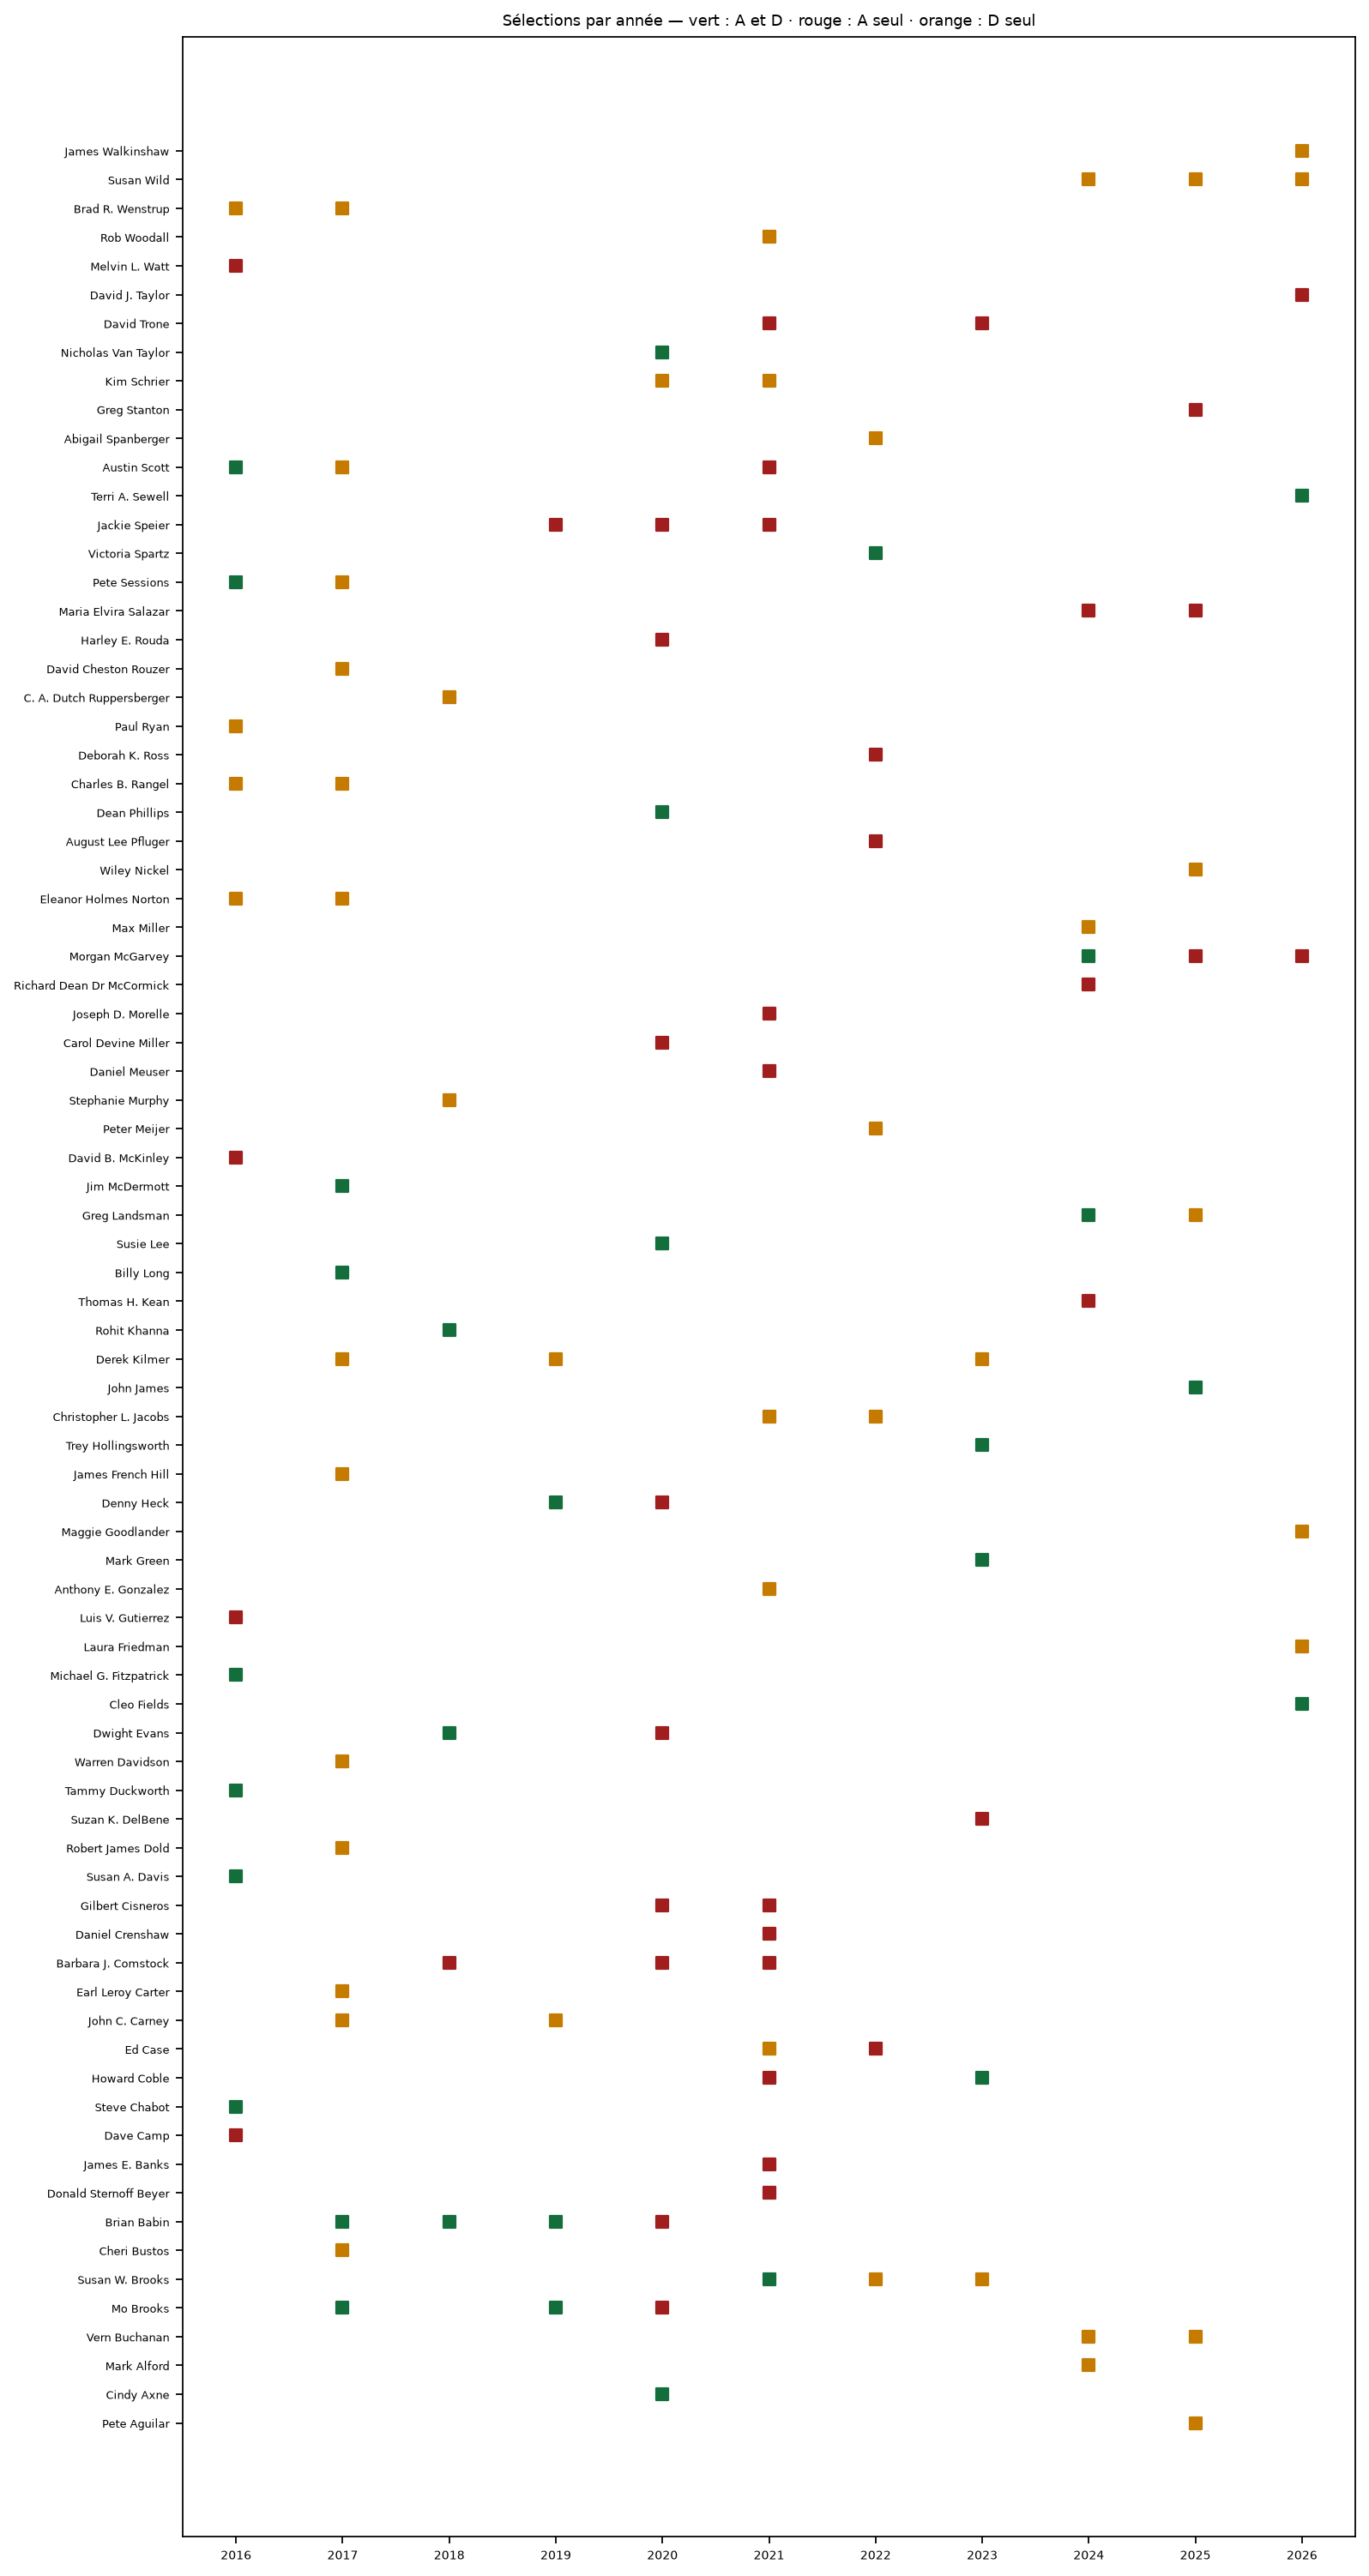

années où la sélection change entre A et D : 11/11


In [71]:
# Figure — qui est copié : les sélections A vs D (poids 1/K), année par année
_ans = sorted(set(strat[("A (témoin)", "1/K")]["sels"]) | set(strat[("D (adaptée)", "1/K")]["sels"]))
_selA = strat[("A (témoin)", "1/K")]["sels"]; _selD = strat[("D (adaptée)", "1/K")]["sels"]
_tous = sorted({b for a in _ans for b in _selA.get(a, []) + _selD.get(a, [])})
NOMS = dict(df_uni.drop_duplicates("bioguide_id")[["bioguide_id", "name"]].values)
fig, ax = plt.subplots(figsize=(10, 0.22 * len(_tous) + 1.2))
for yi, b in enumerate(_tous):
    for xi, an in enumerate(_ans):
        inA, inD = b in _selA.get(an, []), b in _selD.get(an, [])
        c = "#146e3c" if (inA and inD) else ("#a01e1e" if inA else ("#c47b00" if inD else None))
        if c:
            ax.scatter(xi, yi, s=40, marker="s", color=c)
ax.set_xticks(range(len(_ans))); ax.set_xticklabels(_ans)
ax.set_yticks(range(len(_tous)))
ax.set_yticklabels([NOMS.get(b, b) for b in _tous], fontsize=6)
ax.set_title("Sélections par année — vert : A et D · rouge : A seul · orange : D seul")
plt.tight_layout(); plt.show()
print(f"années où la sélection change entre A et D : "
      f"{sum(set(_selA.get(a, [])) != set(_selD.get(a, [])) for a in _ans)}/{len(_ans)}")

**Le mélange G_photo / G_zéro : surveillé (S1), contrôlé (S2), et le déplacement des Sharpe.**

,part_eligibles,part_topK
annee,,
2016,9%,10%
2017,13%,29%
2018,19%,20%
2019,16%,0%
2020,28%,80%
2021,30%,67%
2022,35%,60%
2023,32%,0%
2024,36%,67%


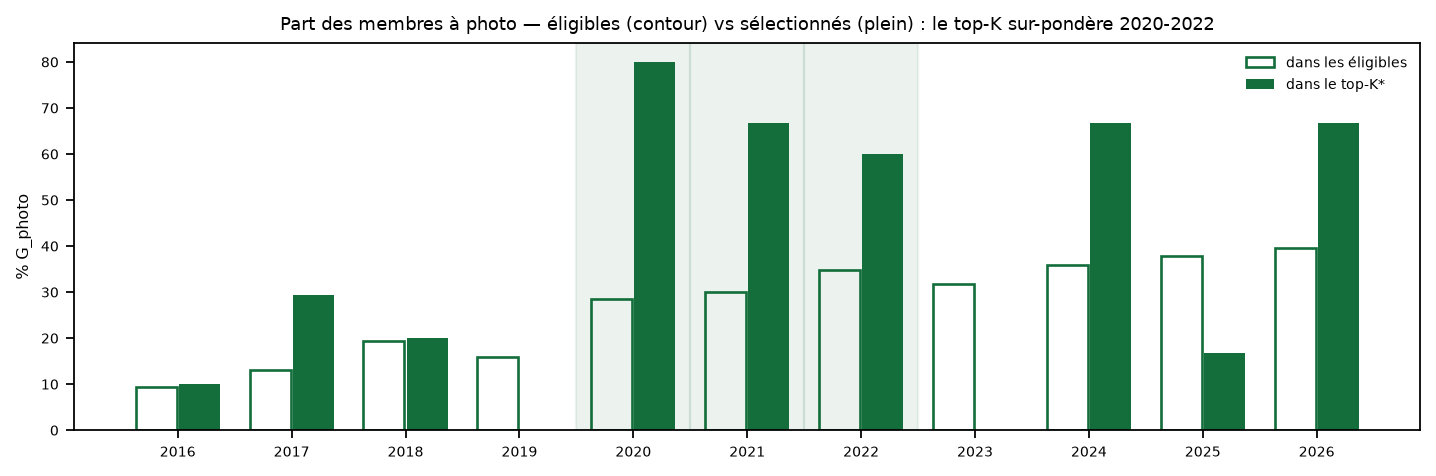

In [72]:
# S1 — le top-K sur-représente-t-il un groupe ? (run D, poids 1/K) — fig_10_s1
_SET_PHOTO = runD[3]                       # référentiel : les photos RÉELLEMENT injectées dans D
_sD = strat[("D (adaptée)", "1/K")]
_s1 = pd.DataFrame([dict(annee=Y + 1,
                         part_eligibles=np.mean([b in _SET_PHOTO for b in _sD["cls"][Y]]),
                         part_topK=np.mean([b in _SET_PHOTO for b in _sD["sels"].get(Y + 1, [np.nan])]))
                    for Y in range(2015, 2026) if _sD["cls"][Y] and (Y + 1) in _sD["sels"]]
                   ).set_index("annee")
display(_s1.style.format("{:.0%}"))
_x = np.arange(len(_s1))
fig, ax = plt.subplots(figsize=(9, 3))
for _i, _an in enumerate(_s1.index):
    if _an in (2020, 2021, 2022):
        ax.axvspan(_i - 0.5, _i + 0.5, color="#146e3c", alpha=0.08, zorder=0)
ax.bar(_x - 0.19, _s1["part_eligibles"] * 100, width=0.36, facecolor="none",
       edgecolor="#146e3c", lw=1.2, label="dans les éligibles")
ax.bar(_x + 0.19, _s1["part_topK"] * 100, width=0.36, color="#146e3c", label="dans le top-K*")
ax.set_xticks(_x); ax.set_xticklabels(_s1.index)
ax.set_ylabel("% G_photo"); ax.legend(frameon=False)
ax.set_title("Part des membres à photo — éligibles (contour) vs sélectionnés (plein) : le top-K sur-pondère 2020-2022")
plt.tight_layout(); plt.show()

In [73]:
# S2 — contrôle stratifié : la même stratégie dans chaque groupe séparément (poids 1/K)
_s2 = {}
for _k in ["A (témoin)", "D (adaptée)"]:
    for _grp, _dans in [("G_photo", True), ("G_zéro", False)]:
        _wfr_g = {b: r for b, r in RUNS[_k][0].items() if (b in _SET_PHOTO) == _dans}
        _s2[f"{_k} · {_grp}"] = ligne(strategie_kwf(_wfr_g, poids="1/K")["r"])
tab_s2 = pd.DataFrame(_s2).T
print("S2 — verdicts par strate (à comparer aux lignes mixtes de É7) :")
display(tab_s2.round(3))

S2 — verdicts par strate (à comparer aux lignes mixtes de É7) :


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
A (témoin) · G_photo,0.006987,0.221705,5/11,1.098361,-0.006332,-0.203882
A (témoin) · G_zéro,-0.010125,-0.481242,4/11,0.960912,-0.006308,-0.277663
D (adaptée) · G_photo,0.005169,0.344448,6/11,0.984474,0.00891,0.479068
D (adaptée) · G_zéro,0.00318,0.15501,4/11,0.843598,0.023463,1.417779


,A,D,photo
A000055,NaN,0.679083,False
A000148,NaN,1.388529,True
A000367,0.839852,0.810734,False


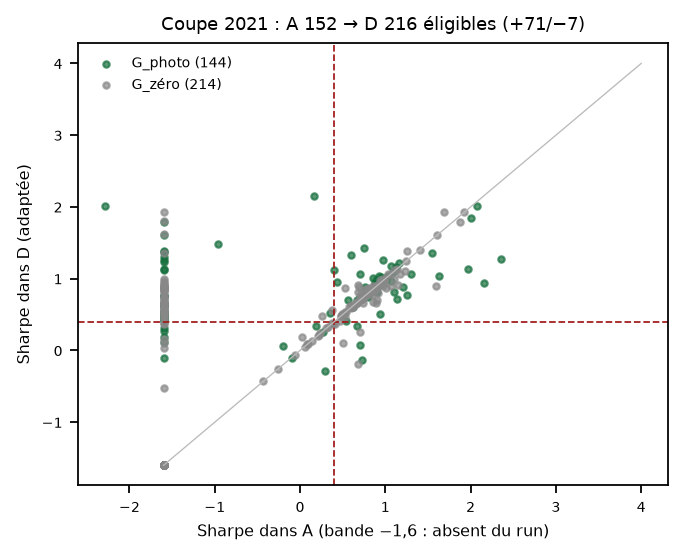

éligibles (Sharpe > 0,4 et n ≥ 126 j) à la coupe 2021 : A 152 · D 216 · entrants 71 · sortants 7


In [74]:
# Le déplacement des Sharpe : A (témoin) vs D (adaptée), coupe 31/12/2021 (fig_10_sharpe_shift)
_yend9 = pd.Timestamp("2021-12-31")
def _sharpe_au(r, yend):
    rr = r.loc[:yend]
    return rr.mean() / rr.std() * np.sqrt(252) if len(rr) >= 126 and rr.std() > 0 else np.nan
sh9 = pd.DataFrame({"A": pd.Series({b: _sharpe_au(r, _yend9) for b, r in runA[0].items()}),
                    "D": pd.Series({b: _sharpe_au(r, _yend9) for b, r in runD[0].items()})})
sh9["photo"] = sh9.index.isin(runD[3])
display(sh9.head(3))
_ABS = -1.6                                        # bande « absent de ce run »
_x9, _y9 = sh9["A"].fillna(_ABS), sh9["D"].fillna(_ABS)
fig, ax = plt.subplots(figsize=(FIGCOL, 3.5))
for _g, _c, _lab in [(True, "#146e3c", f"G_photo ({int(sh9['photo'].sum())})"),
                     (False, "#888888", f"G_zéro ({int((~sh9['photo']).sum())})")]:
    _m = sh9["photo"] == _g
    ax.scatter(_x9[_m], _y9[_m], s=8, color=_c, alpha=0.7, label=_lab)
ax.axhline(0.4, ls="--", c="#a01e1e", lw=0.8); ax.axvline(0.4, ls="--", c="#a01e1e", lw=0.8)
ax.plot([_ABS, 4], [_ABS, 4], lw=0.6, c="#bbbbbb")
ax.set_xlabel("Sharpe dans A (bande −1,6 : absent du run)"); ax.set_ylabel("Sharpe dans D (adaptée)")
_el_A, _el_D = int((sh9["A"] > 0.4).sum()), int((sh9["D"] > 0.4).sum())
_nouv = int(((sh9["D"] > 0.4) & ~(sh9["A"] > 0.4)).sum()); _sort = int(((sh9["A"] > 0.4) & ~(sh9["D"] > 0.4)).sum())
ax.set_title(f"Coupe 2021 : A {_el_A} → D {_el_D} éligibles (+{_nouv}/−{_sort})")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"éligibles (Sharpe > 0,4 et n ≥ 126 j) à la coupe 2021 : A {_el_A} · D {_el_D} · entrants {_nouv} · sortants {_sort}")

**La puissance du test.**

In [75]:
# Puissance : excès annuel moyen minimal détectable (MDE) avec n = 11 années
import scipy.stats as _st
_sig = X9["D"].std(ddof=1)
_t_crit, _t_pow = _st.t.ppf(0.95, df=len(X9) - 1), _st.t.ppf(0.80, df=len(X9) - 1)
MDE80 = (_t_crit + _t_pow) * _sig / np.sqrt(len(X9))
print(f"σ̂ des excès annuels (D) = {_sig*100:.1f} %/an")
print(f"MDE (α = 5 % unilatéral, puissance 80 %) = ({_t_crit:.2f} + {_t_pow:.2f}) × σ̂/√{len(X9)} = {MDE80*100:.1f} %/an")
print("→ sous ce niveau, un vrai excès resterait probablement indétecté : le t faible borne ce qu'on peut voir, il ne prouve pas l'absence d'effet")

σ̂ des excès annuels (D) = 5.9 %/an
MDE (α = 5 % unilatéral, puissance 80 %) = (1.81 + 0.88) × σ̂/√11 = 4.8 %/an
→ sous ce niveau, un vrai excès resterait probablement indétecté : le t faible borne ce qu'on peut voir, il ne prouve pas l'absence d'effet


## P6 — Lecture

In [76]:
_dA, _dD = tab7.loc["A (témoin) · 1/K"], tab7.loc["D (adaptée) · 1/K"]
_best = tab7["t"].astype(float).idxmax()
print("Synthèse (Sharpe · K walk-forward, House) :")
print(f"  poids 1/K     : excès {_dA['exces_an']*100:+.1f} % (A) → {_dD['exces_an']*100:+.1f} % (D) | "
      f"t {_dA['t']:.2f} → {_dD['t']:.2f} | β {_dA['beta']:.2f} → {_dD['beta']:.2f} | "
      f"t_appr {_dA['t_appr']:.2f} → {_dD['t_appr']:.2f}")
_iA, _iD = tab7.loc["A (témoin) · inv-vol"], tab7.loc["D (adaptée) · inv-vol"]
print(f"  poids inv-vol : excès {_iA['exces_an']*100:+.1f} % (A) → {_iD['exces_an']*100:+.1f} % (D) | "
      f"t {_iA['t']:.2f} → {_iD['t']:.2f} | β {_iA['beta']:.2f} → {_iD['beta']:.2f} | "
      f"t_appr {_iA['t_appr']:.2f} → {_iD['t_appr']:.2f}")
print(f"  meilleure ligne du tableau : {_best} (t = {tab7.loc[_best, 't']:.2f}) — seuil t₁₀ ≈ 1,81")
print(f"  S2 (strates)  : " + " | ".join(f"{k} t={v['t']:.2f}" for k, v in tab_s2.round(2).iterrows()))

Synthèse (Sharpe · K walk-forward, House) :
  poids 1/K     : excès +0.9 % (A) → +0.2 % (D) | t 0.37 → 0.13 | β 0.99 → 0.93 | t_appr 0.28 → 0.69
  poids inv-vol : excès -0.3 % (A) → -1.5 % (D) | t -0.11 → -0.78 | β 1.00 → 0.84 | t_appr -0.27 → 0.51
  meilleure ligne du tableau : B (+photo) · 1/K (t = 0.88) — seuil t₁₀ ≈ 1,81
  S2 (strates)  : A (témoin) · G_photo t=0.22 | A (témoin) · G_zéro t=-0.48 | D (adaptée) · G_photo t=0.34 | D (adaptée) · G_zéro t=0.16


**À retenir, indépendamment des chiffres ci-dessus** :
- B − A = l'effet photo · C − A = l'effet O/A/T · D = la stratégie adaptée ; l'inverse-vol perd partout ;
- les O/A/T entrent à leur date de transaction (divulgués ~1 an après — P2) : C et D mesurent une correction
  de données, pas une stratégie jouable telle quelle ; B (photo au dépôt) est, elle, jouable ;
- la vérification P4 est le juge INDÉPENDANT : elle dit si les corrections améliorent la reconstruction,
  même quand la stratégie ne gagne pas ;
- le non-coté (fonds, LLC, immobilier) reste hors périmètre, comme partout dans le projet.

In [77]:
# Garde-fou final : prices_v2 n'a pas bougé
assert sorted(os.listdir(PRICES_V2)) == _SNAP_PV2, "prices_v2 modifié — INTERDIT"
print(f"✅ prices_v2 intact ({len(_SNAP_PV2)} fichiers)")

✅ prices_v2 intact (3351 fichiers)
